#Cài đặt thư viện

In [ ]:
!pip install xgboost lightgbm catboost
!pip install optuna



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.4 MB/s eta 0:00:00


In [ ]:
!pip install shap

#Optuna linear model:
- XGBoost
- LightGBM
- CatBoost

In [ ]:
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from lightgbm import early_stopping
from catboost import CatBoostRegressor
import optuna
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Ẩn bớt log chi tiết của Optuna để màn hình sạch sẽ

# =====================================================================
# 1. CẤU HÌNH HỆ THỐNG VÀ DANH SÁCH TẬP DỮ LIỆU
# =====================================================================
datasets = [
    {"ticker": "JPM", "filename": "JPM_master_trees_updated.csv"},
    {"ticker": "WFC", "filename": "WFC_master_trees_updated.csv"},
    {"ticker": "BAC", "filename": "BAC_master_trees_updated.csv"},
]

exclude_cols = ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume", "target_return", "target_direction"]
target_reg = "target_return"
test_years = [2023, 2024, 2025]
EARLY_STOPPING_ROUNDS = 30

# Nơi lưu trữ bộ tham số tối ưu sau khi tune xong
BEST_PARAMS_MASTER = {
    "XGBoost": {},
    "LightGBM": {},
    "CatBoost": {}
}

# =====================================================================
# 2. ĐỊNH NGHĨA CÁC HÀM MỤC TIÊU (OBJECTIVE FUNCTIONS) CHO OPTUNA
# =====================================================================

def objective_xgb(trial, df, features, years):
    # Định nghĩa Search Space an toàn cho XGBoost chống học nhiễu
    params = {
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 3, 5),               # Cây nông tránh fit nhiễu phẳng
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05), # Học chậm, chắc chắn
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),         # Lấy mẫu dòng ngẫu nhiên
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.7), # Giới hạn số lượng feature/cây
        "min_child_weight": trial.suggest_int("min_child_weight", 15, 50), # Ép số mẫu tối thiểu trong lá cao lên
        "gamma": trial.suggest_float("gamma", 0.1, 1.0),                 # Phạt phân nhánh
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 0.5),        # L1 để triệt tiêu bớt feature nhiễu
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),       # L2 chuẩn hóa
        "random_state": 42,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
    }

    val_scores = []
    for test_yr in test_years:
        train_mask = (years >= 2020) & (years < (test_yr - 1))
        val_mask = years == (test_yr - 1)

        X_train, y_train = df.loc[train_mask, features].values, df.loc[train_mask, target_reg].values
        X_val, y_val = df.loc[val_mask, features].values, df.loc[val_mask, target_reg].values

        model = xgb.XGBRegressor(**params, early_stopping_rounds=EARLY_STOPPING_ROUNDS)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict(X_val)
        val_scores.append(mean_squared_error(y_val, preds))

    return np.mean(val_scores)


def objective_lgb(trial, df, features, years):
    # Định nghĩa Search Space an toàn cho LightGBM
    params = {
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "num_leaves": trial.suggest_int("num_leaves", 7, 23),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.7),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 50), # Tương đương min_data_in_leaf
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),
        "random_state": 42,
        "objective": "regression",
        "metric": "rmse",
        "verbose": -1
    }

    val_scores = []
    for test_yr in test_years:
        train_mask = (years >= 2020) & (years < (test_yr - 1))
        val_mask = years == (test_yr - 1)

        X_train, y_train = df.loc[train_mask, features].values, df.loc[train_mask, target_reg].values
        X_val, y_val = df.loc[val_mask, features].values, df.loc[val_mask, target_reg].values

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)])

        preds = model.predict(X_val)
        val_scores.append(mean_squared_error(y_val, preds))

    return np.mean(val_scores)


def objective_cat(trial, df, features, years):
    # Định nghĩa Search Space an toàn cho CatBoost
    params = {
        "iterations": 1000,
        "depth": trial.suggest_int("depth", 3, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 3.0, 10.0),    # Ép trọng số phạt L2 cao để chống nhiễu
        "random_seed": 42,
        "loss_function": "RMSE",
        "verbose": 0,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS
    }

    val_scores = []
    for test_yr in test_years:
        train_mask = (years >= 2020) & (years < (test_yr - 1))
        val_mask = years == (test_yr - 1)

        X_train, y_train = df.loc[train_mask, features].values, df.loc[train_mask, target_reg].values
        X_val, y_val = df.loc[val_mask, features].values, df.loc[val_mask, target_reg].values

        model = CatBoostRegressor(**params)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)

        preds = model.predict(X_val)
        val_scores.append(mean_squared_error(y_val, preds))

    return np.mean(val_scores)

# =====================================================================
# 3. VÒNG LẶP TUNING TỰ ĐỘNG CHO CẢ 3 NGÂN HÀNG
# =====================================================================

for dataset in datasets:
    ticker = dataset["ticker"]
    filename = dataset["filename"]

    print("\n" + "="*90)
    print(f" ⏳ ĐANG TIẾN HÀNH TUNING SIÊU THAM SỐ CHO NGÂN HÀNG: {ticker}")
    print("="*90)

    try:
        df_models = pd.read_csv(filename)
        df_models["Date"] = pd.to_datetime(df_models["Date"])
        df_models = df_models.sort_values("Date").reset_index(drop=True)
    except FileNotFoundError:
        print(f"❌ Không tìm thấy file {filename}. Bỏ qua...")
        continue

    features = [c for c in df_models.columns if c not in exclude_cols]
    years = df_models["Date"].dt.year

    # --- TUNE XGBOOST ---
    print(" 🛠️ Tuning XGBoost...")
    study_xgb = optuna.create_study(direction="minimize")
    study_xgb.optimize(lambda trial: objective_xgb(trial, df_models, features, years), n_trials=30)
    BEST_PARAMS_MASTER["XGBoost"][ticker] = study_xgb.best_params
    print(f"   ↳ Best MSE: {study_xgb.best_value:.6f} | Params: {study_xgb.best_params}")

    # --- TUNE LIGHTGBM ---
    print(" 🛠️ Tuning LightGBM...")
    study_lgb = optuna.create_study(direction="minimize")
    study_lgb.optimize(lambda trial: objective_lgb(trial, df_models, features, years), n_trials=30)
    BEST_PARAMS_MASTER["LightGBM"][ticker] = study_lgb.best_params
    print(f"   ↳ Best MSE: {study_lgb.best_value:.6f} | Params: {study_lgb.best_params}")

    # --- TUNE CATBOOST ---
    print(" 🛠️ Tuning CatBoost...")
    study_cat = optuna.create_study(direction="minimize")
    study_cat.optimize(lambda trial: objective_cat(trial, df_models, features, years), n_trials=30)
    BEST_PARAMS_MASTER["CatBoost"][ticker] = study_cat.best_params
    print(f"   ↳ Best MSE: {study_cat.best_value:.6f} | Params: {study_cat.best_params}")

print("\n" + "="*90)
print(" ✅ QUY TRÌNH TUNING HOÀN TẤT! DƯỚI ĐÂY LÀ BỘ THAM SỐ TỐI ƯU CỦA BẠN:")
print("="*90)
import pprint
pprint.pprint(BEST_PARAMS_MASTER)


 ⏳ ĐANG TIẾN HÀNH TUNING SIÊU THAM SỐ CHO NGÂN HÀNG: JPM
 🛠️ Tuning XGBoost...
   ↳ Best MSE: 0.000246 | Params: {'max_depth': 3, 'learning_rate': 0.04993098870054468, 'subsample': 0.6015888939194808, 'colsample_bytree': 0.6627529582764204, 'min_child_weight': 40, 'gamma': 0.64145157083843, 'reg_alpha': 0.01806382266905099, 'reg_lambda': 2.2799331199312527}
 🛠️ Tuning LightGBM...
   ↳ Best MSE: 0.000243 | Params: {'max_depth': 5, 'num_leaves': 18, 'learning_rate': 0.031064615248774855, 'subsample': 0.7592264698826355, 'colsample_bytree': 0.5449751963688514, 'min_child_samples': 18, 'reg_alpha': 0.30797527805148284, 'reg_lambda': 3.3576958202978058}
 🛠️ Tuning CatBoost...
   ↳ Best MSE: 0.000245 | Params: {'depth': 5, 'learning_rate': 0.038566350433715584, 'l2_leaf_reg': 3.54862871109282}

 ⏳ ĐANG TIẾN HÀNH TUNING SIÊU THAM SỐ CHO NGÂN HÀNG: WFC
 🛠️ Tuning XGBoost...
   ↳ Best MSE: 0.000357 | Params: {'max_depth': 3, 'learning_rate': 0.04014764118383309, 'subsample': 0.6135931285101606

#Training linear model

In [ ]:
import warnings
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import early_stopping
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
)
import xgboost as xgb

warnings.filterwarnings("ignore")

# =====================================================================
# CẤU HÌNH HỆ THỐNG VÀ BẢN ĐỒ THAM SỐ TỪ OPTUNA (TỪNG MÃ / TỪNG MODEL)
# =====================================================================

# Danh sách các tập dữ liệu cần chạy
datasets = [
    {"ticker": "JPM", "filename": "JPM_master_trees_updated.csv"},
    {"ticker": "WFC", "filename": "WFC_master_trees_updated.csv"},
    {"ticker": "BAC", "filename": "BAC_master_trees_updated.csv"},
]

# Tích hợp kết quả tối ưu thu được từ quá trình Tuning Optuna
TUNED_MASTER = {
    "XGBoost": {
        "JPM": {'max_depth': 4, 'learning_rate': 0.049058808061058196, 'subsample': 0.727340010934087, 'colsample_bytree': 0.666468886903079, 'min_child_weight': 49, 'gamma': 0.5711893326265831, 'reg_alpha': 0.013828809392105672, 'reg_lambda': 3.4481325677520527},
        "WFC": {'max_depth': 4, 'learning_rate': 0.026877835805663206, 'subsample': 0.6653747175917961, 'colsample_bytree': 0.5931191313343727, 'min_child_weight': 21, 'gamma': 0.24038312652487864, 'reg_alpha': 0.011185787994639453, 'reg_lambda': 1.2101750941169094},
        "BAC": {'max_depth': 3, 'learning_rate': 0.046451643847658756, 'subsample': 0.6358527462288843, 'colsample_bytree': 0.5014793178751723, 'min_child_weight': 31, 'gamma': 0.4092225406157449, 'reg_alpha': 0.15521821216501946, 'reg_lambda': 2.1020439898595313}
    },
    "LightGBM": {
        "JPM": {'max_depth': 5, 'num_leaves': 13, 'learning_rate': 0.023694232293310708, 'subsample': 0.7825552524142598, 'colsample_bytree': 0.6178065013540016, 'min_child_samples': 21, 'reg_alpha': 0.05746115659047471, 'reg_lambda': 2.5287816638140246},
        "WFC": {'max_depth': 4, 'num_leaves': 16, 'learning_rate': 0.027375949491699005, 'subsample': 0.6514935848327946, 'colsample_bytree': 0.6031671139926469, 'min_child_samples': 43, 'reg_alpha': 0.06381033284814369, 'reg_lambda': 4.55153515336605},
        "BAC": {'max_depth': 5, 'num_leaves': 11, 'learning_rate': 0.04854019013730422, 'subsample': 0.6622239940539567, 'colsample_bytree': 0.6330284346415295, 'min_child_samples': 45, 'reg_alpha': 0.40787984918546716, 'reg_lambda': 1.475925844350391}
    },
    "CatBoost": {
        "JPM": {'depth': 3, 'learning_rate': 0.026106390523326344, 'l2_leaf_reg': 7.82791596455951},
        "WFC": {'depth': 5, 'learning_rate': 0.045293787409926234, 'l2_leaf_reg': 5.705116216074926},
        "BAC": {'depth': 4, 'learning_rate': 0.01876546174433382, 'l2_leaf_reg': 8.0045642248034}
    }
}

EARLY_STOPPING_ROUNDS = 40

# =====================================================================
# KHỞI TẠO CÁC THÙNG CHỨA DỮ LIỆU TOÀN CỤC CHỐNG LỖI GHI ĐÈ
# =====================================================================
fitted_models = {
    "XGBoost": {},
    "LightGBM": {},
    "CatBoost": {}
}
all_results_master = {}   # Lưu kết quả dự báo và thực tế riêng biệt cho từng Ticker
all_features_master = {}  # Lưu danh sách features riêng biệt cho từng Ticker
all_dfs_master = {}       # Lưu DataFrame đã tiền xử lý riêng biệt cho từng Ticker

# =====================================================================
# VÒNG LẶP CHÍNH DUYỆT QUA TỪNG NGÂN HÀNG
# =====================================================================

for dataset in datasets:
    ticker = dataset["ticker"]
    filename = dataset["filename"]

    print("\n" + "="*90)
    print(f" KHỞI CHẠY PIPELINE CHO NGÂN HÀNG: {ticker} (File: {filename})")
    print("="*90)

    try:
        # 1. Đọc và chuẩn hóa cấu trúc dữ liệu
        df_models = pd.read_csv(filename)
        df_models["Date"] = pd.to_datetime(df_models["Date"])
        df_models = df_models.sort_values("Date").reset_index(drop=True)
        all_dfs_master[ticker] = df_models  # Lưu trữ dữ liệu ngân hàng gốc
    except FileNotFoundError:
        print(f"❌ Không tìm thấy file {filename}. Bỏ qua ngân hàng {ticker}.")
        continue

    # 2. Phân tách danh sách Features và Target
    exclude_cols = ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume", "target_return", "target_direction"]
    features = [c for c in df_models.columns if c not in exclude_cols]
    all_features_master[ticker] = features  # Lưu trữ danh sách features
    target_reg = "target_return"

    years = df_models["Date"].dt.year
    test_years = [2023, 2024, 2025]

    # Khởi tạo cấu trúc lưu trữ kết quả cục bộ cho ngân hàng hiện tại
    results_dict = {
        "XGBoost": {"preds": [], "actuals": []},
        "LightGBM": {"preds": [], "actuals": []},
        "CatBoost": {"preds": [], "actuals": []},
    }

    print(f"Số lượng Features ghi nhận: {len(features)}")

    # 4. VÒNG LẶP WALK-FORWARD VALIDATION TỪNG NĂM
    for test_yr in test_years:
        print(f"  ▶ Đang xử lý khối kiểm thử dữ liệu năm: {test_yr}")

        train_mask = (years >= 2020) & (years < (test_yr - 1))
        val_mask = years == (test_yr - 1)
        test_mask = years == test_yr

        X_train = df_models.loc[train_mask, features].values
        y_train = df_models.loc[train_mask, target_reg].values

        X_val = df_models.loc[val_mask, features].values
        y_val = df_models.loc[val_mask, target_reg].values

        X_test = df_models.loc[test_mask, features].values
        y_test = df_models.loc[test_mask, target_reg].values

        X_train_full = np.vstack([X_train, X_val])
        y_train_full = np.concatenate([y_train, y_val])

        # --- MODEL 1: XGBOOST (Tuned từ Optuna) ---
        xgb_fold_params = {
            "n_estimators": 1500,
            "random_state": 42,
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            **TUNED_MASTER["XGBoost"][ticker]
        }

        # Phase 1: Tìm số cây tối ưu
        model_xgb = xgb.XGBRegressor(**xgb_fold_params)
        model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        best_iter_xgb = model_xgb.best_iteration

        # Phase 2: Retrain trên tập dữ liệu gộp đầy đủ
        xgb_retrain_params = {
            **xgb_fold_params,
            "n_estimators": max(100, best_iter_xgb + 25),
            "early_stopping_rounds": None
        }
        model_xgb_retrain = xgb.XGBRegressor(**xgb_retrain_params)
        model_xgb_retrain.fit(X_train_full, y_train_full, verbose=False)
        preds_xgb = model_xgb_retrain.predict(X_test)

        results_dict["XGBoost"]["preds"].extend(preds_xgb)
        results_dict["XGBoost"]["actuals"].extend(y_test)

        # Lưu trữ mô hình XGBoost của năm cuối cùng (2025) để làm SHAP
        if test_yr == 2025:
            fitted_models["XGBoost"][ticker] = model_xgb_retrain

        # --- MODEL 2: LIGHTGBM (Tuned từ Optuna) ---
        lgb_fold_params = {
            "n_estimators": 1500,
            "random_state": 42,
            "objective": "regression",
            "metric": "rmse",
            "verbose": -1,
            **TUNED_MASTER["LightGBM"][ticker]
        }

        model_lgb = lgb.LGBMRegressor(**lgb_fold_params)
        model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)])
        best_iter_lgb = model_lgb.best_iteration_

        lgb_retrain_params = {
            **lgb_fold_params,
            "n_estimators": max(100, best_iter_lgb + 25)
        }
        model_lgb_retrain = lgb.LGBMRegressor(**lgb_retrain_params)
        model_lgb_retrain.fit(X_train_full, y_train_full)
        preds_lgb = model_lgb_retrain.predict(X_test)

        results_dict["LightGBM"]["preds"].extend(preds_lgb)
        results_dict["LightGBM"]["actuals"].extend(y_test)

        # Lưu trữ mô hình LightGBM của năm cuối cùng (2025) để làm SHAP
        if test_yr == 2025:
            fitted_models["LightGBM"][ticker] = model_lgb_retrain

        # --- MODEL 3: CATBOOST (Tuned từ Optuna) ---
        cat_fold_params = {
            "iterations": 1500,
            "random_seed": 42,
            "loss_function": "RMSE",
            "verbose": 0,
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            **TUNED_MASTER["CatBoost"][ticker]
        }

        model_cat = CatBoostRegressor(**cat_fold_params)
        model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        best_iter_cat = model_cat.get_best_iteration()

        cat_retrain_params = {
            **cat_fold_params,
            "iterations": max(100, best_iter_cat + 25),
            "early_stopping_rounds": None
        }
        model_cat_retrain = CatBoostRegressor(**cat_retrain_params)
        model_cat_retrain.fit(X_train_full, y_train_full, verbose=False)
        preds_cat = model_cat_retrain.predict(X_test)

        results_dict["CatBoost"]["preds"].extend(preds_cat)
        results_dict["CatBoost"]["actuals"].extend(y_test)

        # Lưu trữ mô hình CatBoost của năm cuối cùng (2025) để làm SHAP
        if test_yr == 2025:
            fitted_models["CatBoost"][ticker] = model_cat_retrain

        # Ghi nhận log cây tối ưu
        rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))
        rmse_lgb = np.sqrt(mean_squared_error(y_test, preds_lgb))
        rmse_cat = np.sqrt(mean_squared_error(y_test, preds_cat))
        print(f"    ↳ Best Trees -> XGB:{best_iter_xgb} | LGB:{best_iter_lgb} | CAT:{best_iter_cat}")
        print(f"    ↳ [Fold RMSE] XGB: {rmse_xgb:.5f} | LGB: {rmse_lgb:.5f} | CAT: {rmse_cat:.5f}")

    # Đóng gói và lưu kết quả dự báo toàn bộ 3 năm vào Master Dictionary
    all_results_master[ticker] = results_dict

    # 5. XUẤT BẢNG TỔNG HỢP HIỆU SUẤT CHO NGÂN HÀNG HIỆN TẠI
    final_report = []
    confusion_matrices = {}

    for m_name, data in results_dict.items():
        actuals = np.array(data["actuals"])
        preds = np.array(data["preds"])

        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mae = mean_absolute_error(actuals, preds)

        dir_actual = np.where(actuals > 0, 1, 0)

        # Áp dụng ngưỡng động dựa trên Mean phân phối dự báo thực tế để tính Performance Metrics
        threshold = np.mean(preds)
        dir_pred = np.where(preds > threshold, 1, 0)

        acc = np.mean(dir_actual == dir_pred) * 100
        prec = precision_score(dir_actual, dir_pred, zero_division=0)
        rec = recall_score(dir_actual, dir_pred, zero_division=0)
        f1 = f1_score(dir_actual, dir_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(dir_actual, dir_pred).ravel()
        confusion_matrices[m_name] = {"TN": tn, "FP": fp, "FN": fn, "TP": tp}

        final_report.append({
            "Model": m_name, "RMSE": round(rmse, 5), "MAE": round(mae, 5),
            "Directional Acc (%)": round(acc, 2), "Precision": round(prec, 4),
            "Recall": round(rec, 4), "F1-Score": round(f1, 4),
        })

    report_df = pd.DataFrame(final_report)

    print("\n" + "=" * 80)
    print(f"=== BẢNG SO SÁNH HIỆU SUẤT HỒI QUY TỔNG THỂ - NGÂN HÀNG {ticker} (2023-2025) ===")
    print("=" * 80)
    print(report_df.to_string(index=False))
    print("=" * 80)

    # 6. IN MA TRẬN NHẦM LẪN CHI TIẾT DẠNG VĂN BẢN
    print("\n=== CHI TIẾT MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - " + ticker + " ===")
    for m_name, cm in confusion_matrices.items():
        total = cm["TN"] + cm["FP"] + cm["FN"] + cm["TP"]
        print(f"\n▶ MÔ HÌNH: {m_name}")
        print(f"  +-------------------+-------------------+-------------------+")
        print(f"  |                   | Dự báo GIẢM (0)   | Dự báo TĂNG (1)   |")
        print(f"  +-------------------+-------------------+-------------------+")
        print(f"  | Thực tế GIẢM (0)  | TN: {cm['TN']:<5} ({cm['TN']/total*100:.1f}%) | FP: {cm['FP']:<5} ({cm['FP']/total*100:.1f}%) |")
        print(f"  | Thực tế TĂNG (1)  | FN: {cm['FN']:<5} ({cm['FN']/total*100:.1f}%) | TP: {cm['TP']:<5} ({cm['TP']/total*100:.1f}%) |")
        print(f"  +-------------------+-------------------+-------------------+")

# =====================================================================
# 7. THỐNG KÊ PHÂN PHỐI DỰ BÁO CUỐI CÙNG CHO CẢ 3 NGÂN HÀNG (Ngoài Loop)
# =====================================================================
print("\n" + "=" * 90)
print("=== BÁO CÁO PHÂN PHỐI DỰ BÁO CHI TIẾT TOÀN HỆ THỐNG (2023-2025) ===")
print("=" * 90)

for ticker in all_results_master.keys():
    print(f"\n🏢 NGÂN HÀNG: {ticker}")
    print("-" * 50)
    direction_report = []

    for model_name in ["XGBoost", "LightGBM", "CatBoost"]:
        preds = np.array(all_results_master[ticker][model_name]["preds"])
        direction_report.append({
            "Model": model_name,
            "Min": round(preds.min(), 6),
            "Max": round(preds.max(), 6),
            "Mean": round(preds.mean(), 6),
            "Std": round(preds.std(), 6),
            "% Positive": round((preds > 0).mean() * 100, 2),
            "% Negative": round((preds <= 0).mean() * 100, 2)
        })

    direction_df = pd.DataFrame(direction_report)
    print(direction_df.to_string(index=False))
    print("-" * 50)


 KHỞI CHẠY PIPELINE CHO NGÂN HÀNG: JPM (File: JPM_master_trees_updated.csv)
Số lượng Features ghi nhận: 45
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2023
    ↳ Best Trees -> XGB:13 | LGB:1 | CAT:7
    ↳ [Fold RMSE] XGB: 0.01305 | LGB: 0.01293 | CAT: 0.01307
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2024
    ↳ Best Trees -> XGB:96 | LGB:67 | CAT:32
    ↳ [Fold RMSE] XGB: 0.01467 | LGB: 0.01451 | CAT: 0.01477
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2025
    ↳ Best Trees -> XGB:27 | LGB:125 | CAT:25
    ↳ [Fold RMSE] XGB: 0.01573 | LGB: 0.01623 | CAT: 0.01595

=== BẢNG SO SÁNH HIỆU SUẤT HỒI QUY TỔNG THỂ - NGÂN HÀNG JPM (2023-2025) ===
   Model    RMSE     MAE  Directional Acc (%)  Precision  Recall  F1-Score
 XGBoost 0.01452 0.00990                47.40     0.5663  0.3294    0.4165
LightGBM 0.01462 0.01010                50.47     0.5749  0.5023    0.5362
CatBoost 0.01464 0.00998                47.14     0.5622  0.3271    0.4136

=== CHI TIẾT MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - JPM =

#SHAP Explainability


===== TOP 10 SHAP FEATURES - JPM (LightGBM) =====
         Feature  SHAP Importance
   overnight_gap         0.000579
VIX_volatility_5         0.000562
            MACD         0.000490
   volatility_20         0.000483
 VIX_return_lag1         0.000472
  VIX_momentum_5         0.000441
      VIX_return         0.000408
       return_1d         0.000357
    lag_return_3         0.000289
       VIX_Close         0.000277


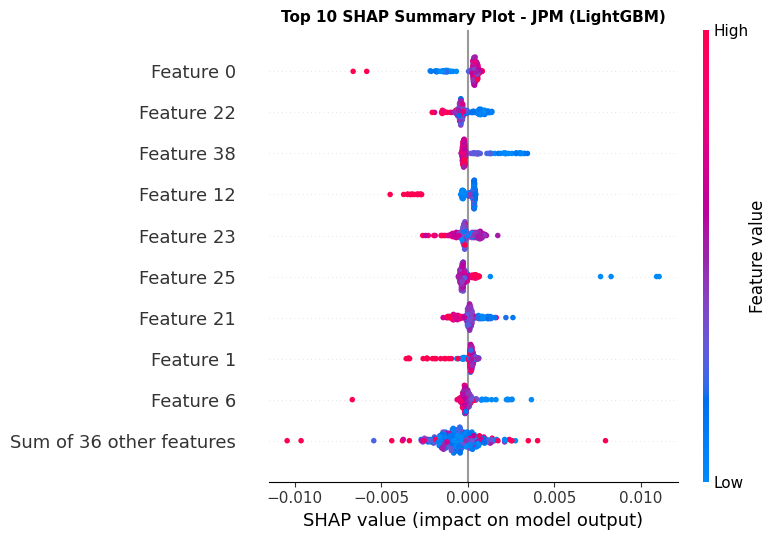


===== TOP 10 SHAP FEATURES - WFC (LightGBM) =====
          Feature  SHAP Importance
             MACD         0.000575
      MACD_Signal         0.000389
     lag_return_3         0.000370
       XLF_return         0.000359
 VIX_volatility_5         0.000353
     lag_return_1         0.000336
     lag_return_2         0.000331
SPX_volatility_20         0.000331
  VIX_return_lag1         0.000331
 XLF_volatility_5         0.000319


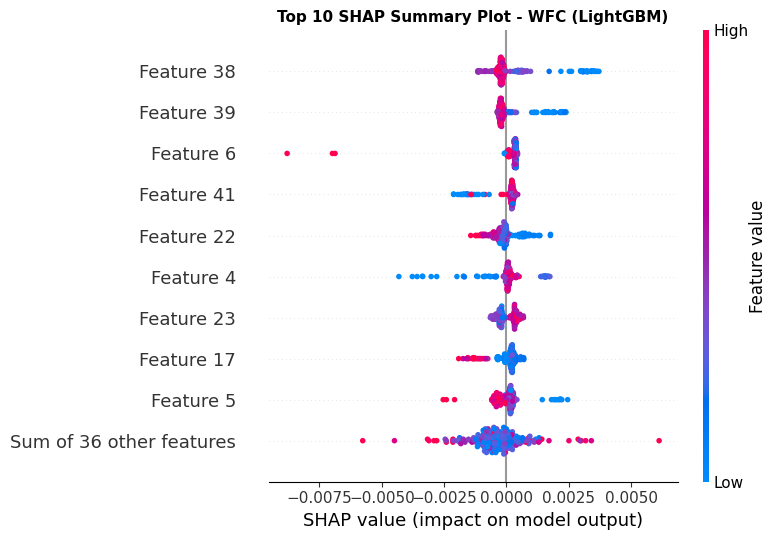


===== TOP 10 SHAP FEATURES - BAC (LightGBM) =====
         Feature  SHAP Importance
   overnight_gap         0.000761
VIX_volatility_5         0.000633
     MACD_Signal         0.000592
    lag_return_3         0.000539
    volume_shock         0.000515
      VIX_return         0.000505
       return_3d         0.000492
 Rolling_Beta_30         0.000457
    lag_return_5         0.000381
           DGS10         0.000375


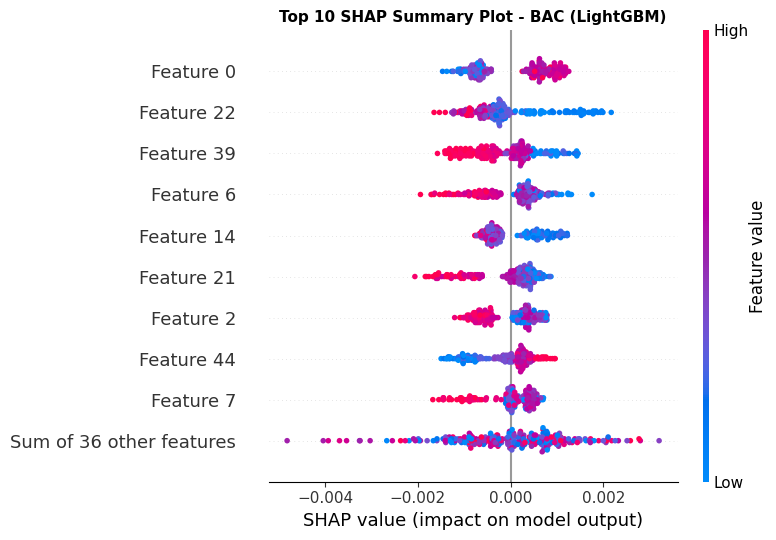

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "LightGBM"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]

    # Lọc snapshot năm 2025
    test_mask = df_single["Date"].dt.year == 2025
    df_oos = df_single.loc[test_mask].reset_index(drop=True)
    X_test_snapshot = df_oos[features_single].values

    current_model = fitted_models[TARGET_MODEL_NAME][ticker]

    # Tính SHAP
    explainer = shap.TreeExplainer(current_model)
    shap_vals = explainer(X_test_snapshot)
    shap_importance = np.abs(shap_vals.values).mean(axis=0)

    print(f"\n===== TOP 10 SHAP FEATURES - {ticker} ({TARGET_MODEL_NAME}) =====")
    importance_df = pd.DataFrame({
        "Feature": features_single,
        "SHAP Importance": np.round(shap_importance, 6)
    }).sort_values(by="SHAP Importance", ascending=False).reset_index(drop=True)

    print(importance_df.head(10).to_string(index=False))

    # Vẽ Summary Plot
    plt.figure(figsize=(9, 4.5))
    shap.plots.beeswarm(shap_vals, max_display=10, show=False)
    plt.title(f"Top 10 SHAP Summary Plot - {ticker} ({TARGET_MODEL_NAME})", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


===== TOP 10 SHAP FEATURES - JPM (CatBoost) =====
          Feature  SHAP Importance
   VIX_momentum_5         0.000363
       SPX_return         0.000114
       VIX_return         0.000062
SPX_volatility_20         0.000046
     lag_return_1         0.000041
       XLF_return         0.000034
        VIX_Close         0.000034
     volatility_5         0.000033
  VIX_return_lag1         0.000031
    volatility_10         0.000031


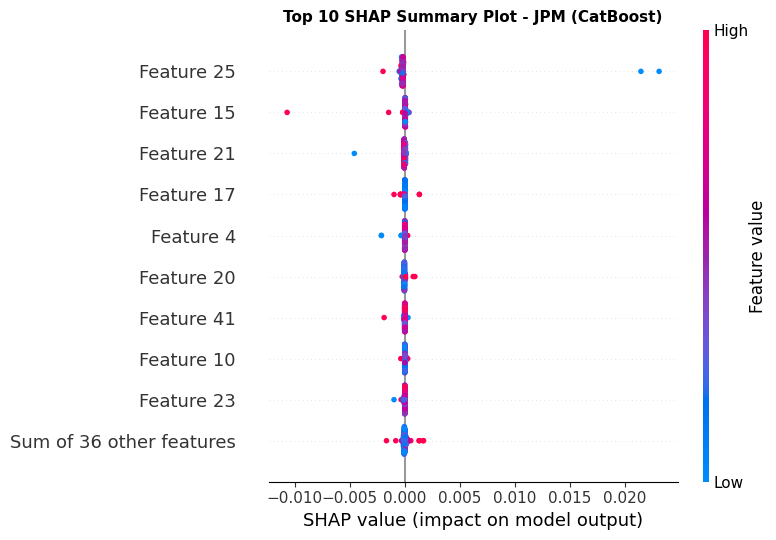


===== TOP 10 SHAP FEATURES - WFC (CatBoost) =====
          Feature  SHAP Importance
   VIX_momentum_5         0.000363
    volatility_20         0.000216
     Yield_Spread         0.000175
             MACD         0.000163
       VIX_return         0.000124
     lag_return_2         0.000119
SPX_volatility_20         0.000110
    overnight_gap         0.000106
 XLF_volatility_5         0.000098
  price_ma5_ratio         0.000097


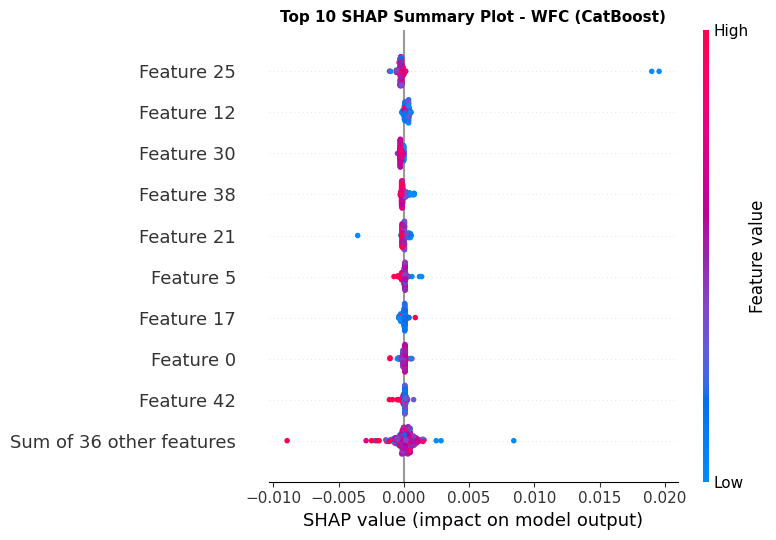


===== TOP 10 SHAP FEATURES - BAC (CatBoost) =====
        Feature  SHAP Importance
 VIX_momentum_5         0.000258
     VIX_return         0.000105
     SPX_return         0.000055
      return_3d         0.000051
price_ma5_ratio         0.000050
     XLF_return         0.000047
      return_1d         0.000041
           DGS2         0.000038
   lag_return_3         0.000033
  volatility_20         0.000033


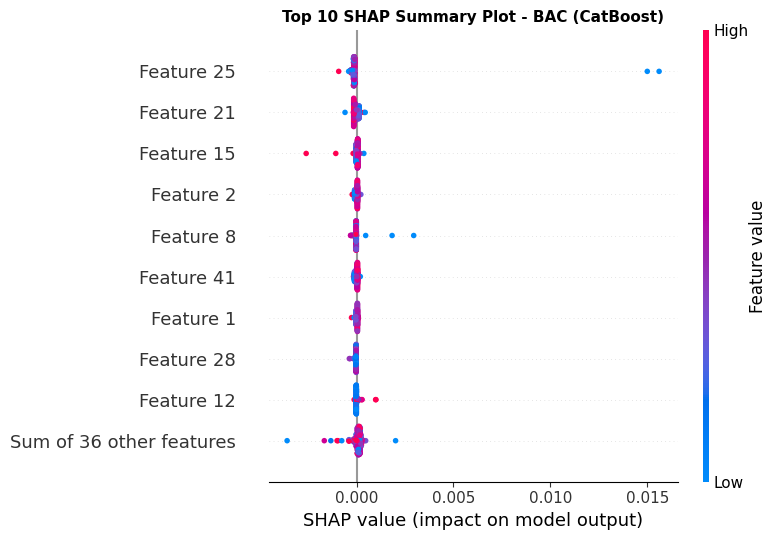

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "CatBoost"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]

    # Lọc snapshot năm 2025
    test_mask = df_single["Date"].dt.year == 2025
    df_oos = df_single.loc[test_mask].reset_index(drop=True)
    X_test_snapshot = df_oos[features_single].values

    current_model = fitted_models[TARGET_MODEL_NAME][ticker]

    # Tính SHAP
    explainer = shap.TreeExplainer(current_model)
    shap_vals = explainer(X_test_snapshot)
    shap_importance = np.abs(shap_vals.values).mean(axis=0)

    print(f"\n===== TOP 10 SHAP FEATURES - {ticker} ({TARGET_MODEL_NAME}) =====")
    importance_df = pd.DataFrame({
        "Feature": features_single,
        "SHAP Importance": np.round(shap_importance, 6)
    }).sort_values(by="SHAP Importance", ascending=False).reset_index(drop=True)

    print(importance_df.head(10).to_string(index=False))

    # Vẽ Summary Plot
    plt.figure(figsize=(9, 4.5))
    shap.plots.beeswarm(shap_vals, max_display=10, show=False)
    plt.title(f"Top 10 SHAP Summary Plot - {ticker} ({TARGET_MODEL_NAME})", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


===== TOP 10 SHAP FEATURES - JPM (XGBoost) =====
         Feature  SHAP Importance
   overnight_gap              0.0
       return_1d              0.0
       return_3d              0.0
       return_5d              0.0
    lag_return_1              0.0
    lag_return_2              0.0
    lag_return_3              0.0
    lag_return_5              0.0
 price_ma5_ratio              0.0
price_ma20_ratio              0.0


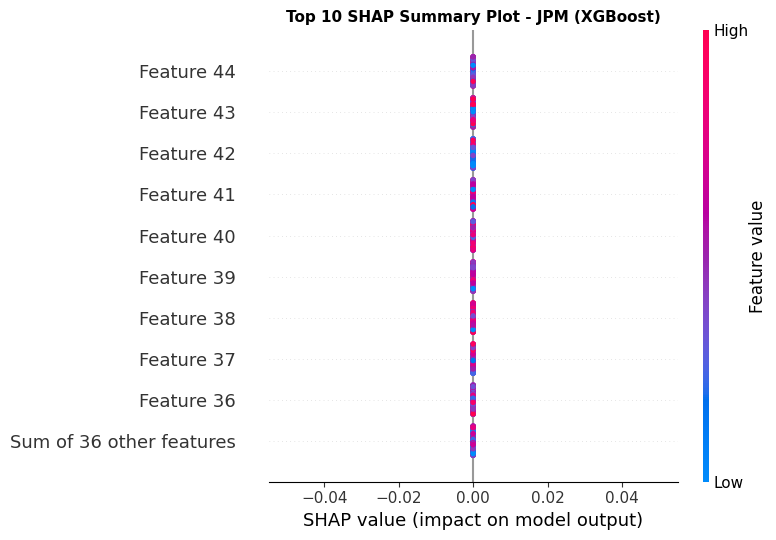


===== TOP 10 SHAP FEATURES - WFC (XGBoost) =====
         Feature  SHAP Importance
   overnight_gap              0.0
       return_1d              0.0
       return_3d              0.0
       return_5d              0.0
    lag_return_1              0.0
    lag_return_2              0.0
    lag_return_3              0.0
    lag_return_5              0.0
 price_ma5_ratio              0.0
price_ma20_ratio              0.0


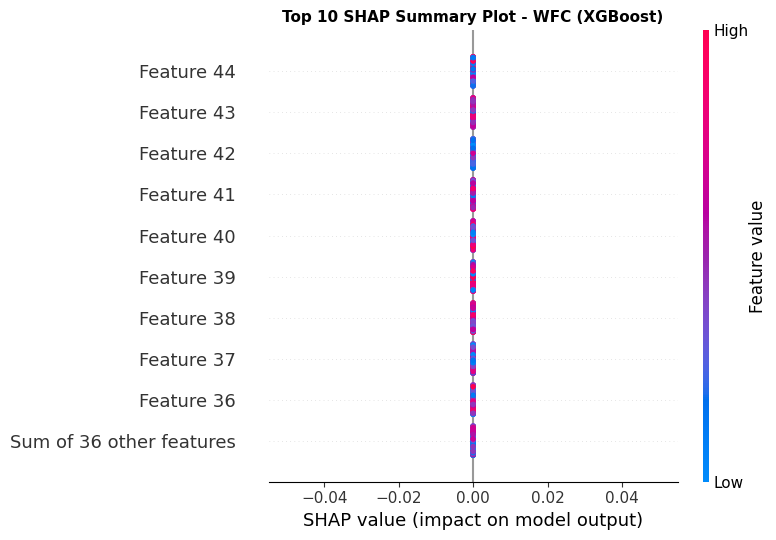


===== TOP 10 SHAP FEATURES - BAC (XGBoost) =====
         Feature  SHAP Importance
   overnight_gap              0.0
       return_1d              0.0
       return_3d              0.0
       return_5d              0.0
    lag_return_1              0.0
    lag_return_2              0.0
    lag_return_3              0.0
    lag_return_5              0.0
 price_ma5_ratio              0.0
price_ma20_ratio              0.0


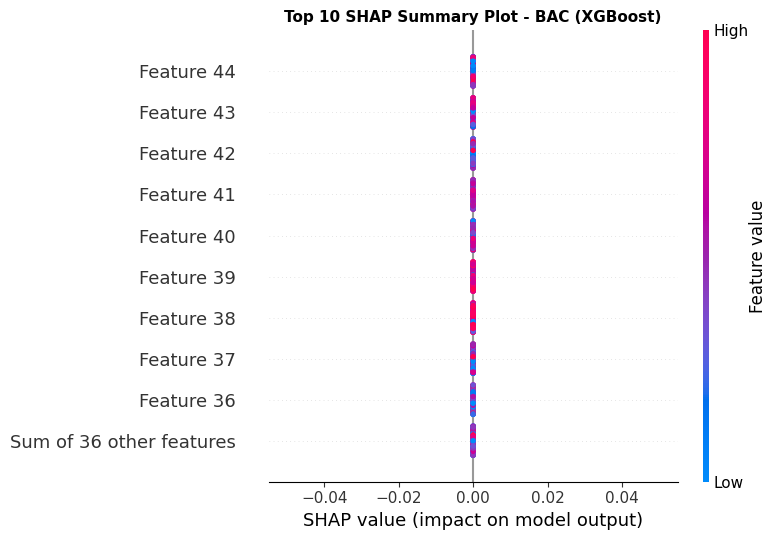

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "XGBoost"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]

    # Lọc snapshot năm 2025
    test_mask = df_single["Date"].dt.year == 2025
    df_oos = df_single.loc[test_mask].reset_index(drop=True)
    X_test_snapshot = df_oos[features_single].values

    current_model = fitted_models[TARGET_MODEL_NAME][ticker]

    # Tính SHAP
    explainer = shap.TreeExplainer(current_model)
    shap_vals = explainer(X_test_snapshot)
    shap_importance = np.abs(shap_vals.values).mean(axis=0)

    print(f"\n===== TOP 10 SHAP FEATURES - {ticker} ({TARGET_MODEL_NAME}) =====")
    importance_df = pd.DataFrame({
        "Feature": features_single,
        "SHAP Importance": np.round(shap_importance, 6)
    }).sort_values(by="SHAP Importance", ascending=False).reset_index(drop=True)

    print(importance_df.head(10).to_string(index=False))

    # Vẽ Summary Plot
    plt.figure(figsize=(9, 4.5))
    shap.plots.beeswarm(shap_vals, max_display=10, show=False)
    plt.title(f"Top 10 SHAP Summary Plot - {ticker} ({TARGET_MODEL_NAME})", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

#Market Regime Analysis

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("==========================================================================================")
print(" KHỞI CHẠY BƯỚC 2: MARKET REGIME ANALYSIS (CV-SYNCHRONIZED - CHỐNG DATA LEAKAGE)")
print("==========================================================================================")

tickers = ["JPM", "WFC", "BAC"]
models = ["XGBoost", "LightGBM", "CatBoost"]
test_years = [2023, 2024, 2025]

# Cấu trúc lưu trữ kết quả phân mảnh theo từng Regime để phục vụ thống kê tổng gộp
regime_master_reports = {ticker: {m: [] for m in models} for ticker in tickers}

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_results_master:
        print(f"Không tìm thấy dữ liệu lưu trữ của {ticker}. Hãy chạy lại pipeline chính.")
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]
    results_single = all_results_master[ticker]

    years = df_single["Date"].dt.year

    # Dò tìm cột chứa từ khóa VIX
    vix_cols = [c for c in features_single if "VIX" in c.upper()]
    if not vix_cols:
        print(f"⚠️ Không tìm thấy feature VIX cho {ticker}. Bỏ qua...")
        continue
    vix_col_name = vix_cols[0]

    # VÒNG LẶP WALK-FORWARD ĐỂ PHÂN TÁCH REGIME ĐỘNG THEO TỪNG NĂM TEST
    for test_yr in test_years:
        # 1. Định vị Mặt nạ dữ liệu (Masks) y hệt như lúc Train mô hình
        train_mask = (years >= 2020) & (years < (test_yr - 1))  # Tập Train thực tế của Fold hiện tại
        test_mask = years == test_yr                            # Tập Test của năm hiện tại

        # 2. Tính toán Phân vị VIX CHỈ TRÊN TẬP TRAIN lịch sử (Ngăn chặn hoàn toàn nhìn trước tương lai)
        vix_train_values = df_single.loc[train_mask, vix_col_name].values
        q33_train = np.quantile(vix_train_values, 1/3)
        q66_train = np.quantile(vix_train_values, 2/3)

        # 3. Lấy giá trị VIX của tập Test năm hiện tại để phân loại
        vix_test_values = df_single.loc[test_mask, vix_col_name].values

        test_regimes = {
            "Low Stress": vix_test_values < q33_train,
            "Normal Regime": (vix_test_values >= q33_train) & (vix_test_values <= q66_train),
            "High Stress": vix_test_values > q66_train
        }

        # 4. Trích xuất mảng dự báo và thực tế cục bộ của năm test hiện tại
        # Tính toán index định vị tương đối cho năm test trong chuỗi Out-of-Sample gộp
        df_oos_full = df_single[years.isin(test_years)].reset_index(drop=True)
        year_local_mask = df_oos_full["Date"].dt.year == test_yr

        for model_name in models:
            actuals_full = np.array(results_single[model_name]["actuals"])
            preds_full = np.array(results_single[model_name]["preds"])

            actuals_year = actuals_full[year_local_mask]
            preds_year = preds_full[year_local_mask]

            # Đánh giá hiệu năng theo từng vùng Regime trên tập Test năm nay
            for r_name, r_mask in test_regimes.items():
                r_actuals = actuals_year[r_mask]
                r_preds = preds_year[r_mask]

                if len(r_actuals) == 0:
                    continue

                r_rmse = np.sqrt(mean_squared_error(r_actuals, r_preds))
                r_mae = mean_absolute_error(r_actuals, r_preds)

                # Tính toán độ chính xác hướng (Directional Accuracy) dựa trên ngưỡng Mean động cục bộ của năm
                r_threshold = np.mean(preds_year)
                dir_act = np.where(r_actuals > 0, 1, 0)
                dir_pred = np.where(r_preds > r_threshold, 1, 0)
                r_acc = np.mean(dir_act == dir_pred) * 100

                # Lưu trữ kết quả phân mảnh của năm nay
                regime_master_reports[ticker][model_name].append({
                    "Regime": r_name,
                    "Samples": len(r_actuals),
                    "RMSE": r_rmse,
                    "MAE": r_mae,
                    "Dir Acc (%)": r_acc
                })

    # 5. IN BÁO CÁO TỔNG GỢP 3 NĂM ĐÃ ĐƯỢC ĐỒNG BỘ CHO NGÂN HÀNG
    print(f"\n==================== MARKET REGIME ANALYSIS: {ticker} ====================")
    print(f"(VIX Cutoffs computed dynamically using Training Folds history)")

    for model_name in models:
        # Gộp dữ liệu từ các năm test lại để tính trung bình trọng số chuẩn xác cho từng Regime
        df_ticker_model = pd.DataFrame(regime_master_reports[ticker][model_name])

        final_regime_report = []
        for r_name in ["Low Stress", "Normal Regime", "High Stress"]:
            df_sub = df_ticker_model[df_ticker_model["Regime"] == r_name]
            if len(df_sub) == 0:
                continue

            total_samples = df_sub["Samples"].sum()
            # Tính trung bình có trọng số theo số lượng mẫu của từng năm
            weighted_rmse = np.sum(df_sub["RMSE"] * df_sub["Samples"]) / total_samples
            weighted_mae = np.sum(df_sub["MAE"] * df_sub["Samples"]) / total_samples
            weighted_acc = np.sum(df_sub["Dir Acc (%)"] * df_sub["Samples"]) / total_samples

            final_regime_report.append({
                "Model": model_name,
                "Market Regime": r_name,
                "Total Samples": total_samples,
                "RMSE": round(weighted_rmse, 5),
                "MAE": round(weighted_mae, 5),
                "Dir Acc (%)": round(weighted_acc, 2)
            })

        print(f"\n▶ MÔ HÌNH: {model_name}")
        print("-" * 75)
        print(pd.DataFrame(final_regime_report).to_string(index=False))
    print("=" * 74)

 KHỞI CHẠY BƯỚC 2: MARKET REGIME ANALYSIS (CV-SYNCHRONIZED - CHỐNG DATA LEAKAGE)

==================== MARKET REGIME ANALYSIS: JPM ====================
(VIX Cutoffs computed dynamically using Training Folds history)

▶ MÔ HÌNH: XGBoost
---------------------------------------------------------------------------
  Model Market Regime  Total Samples    RMSE     MAE  Dir Acc (%)
XGBoost    Low Stress            608 0.01310 0.00897        43.91
XGBoost Normal Regime            110 0.01691 0.01255        39.09
XGBoost   High Stress             33 0.02530 0.01823        39.39

▶ MÔ HÌNH: LightGBM
---------------------------------------------------------------------------
   Model Market Regime  Total Samples    RMSE     MAE  Dir Acc (%)
LightGBM    Low Stress            608 0.01312 0.00909        53.12
LightGBM Normal Regime            110 0.01697 0.01283        46.36
LightGBM   High Stress             33 0.02606 0.01979        33.33

▶ MÔ HÌNH: CatBoost
--------------------------------------

#Economic Evaluation

 KHỞI CHẠY BƯỚC 3: ECONOMIC EVALUATION - NÂNG CẤP TRANSACTION COST & EFFR SHARPE

==================== ECONOMIC EVALUATION: JPM ====================
(Áp dụng Chi phí ma sát: 7.5 bps | Tính Sharpe tích hợp chuỗi EFFR thực tế)

▶ MÔ HÌNH: XGBoost
------------------------------------------------------------------------------------------
                  Regime  Days  Net Cum Ret (%)  Ann Ret (%)  Sharpe (EFFR)  Max DD (%)  Win Rate (%)  Turnover (%)
        Low VIX (<14.91)   247             3.70         3.77        -0.3945       -2.12         63.16          0.40
Normal VIX (14.91-17.87)   254            10.26        10.17         0.4255       -7.20         53.91          0.39
       High VIX (>17.87)   250            16.15        16.28         0.6223      -21.78         58.82          0.40
------------------------------------------------------------------------------------------

▶ MÔ HÌNH: LightGBM
----------------------------------------------------------------------------------------

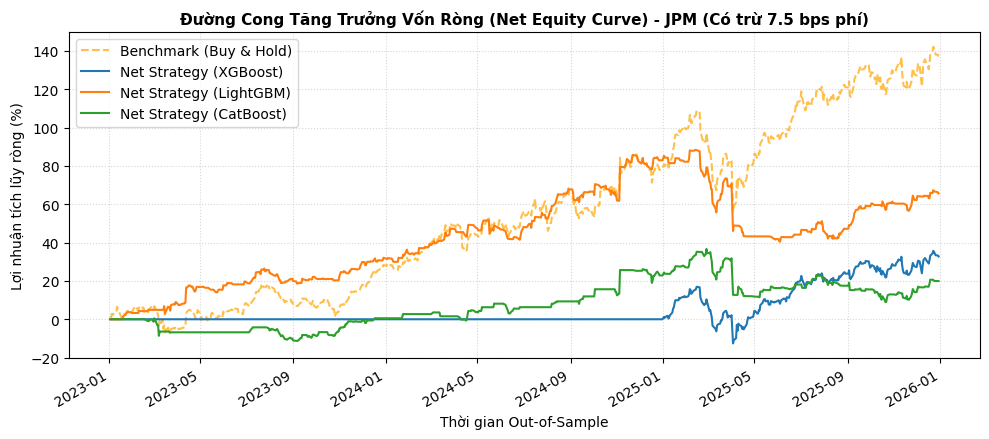


==================== ECONOMIC EVALUATION: WFC ====================
(Áp dụng Chi phí ma sát: 7.5 bps | Tính Sharpe tích hợp chuỗi EFFR thực tế)

▶ MÔ HÌNH: XGBoost
------------------------------------------------------------------------------------------
                  Regime  Days  Net Cum Ret (%)  Ann Ret (%)  Sharpe (EFFR)  Max DD (%)  Win Rate (%)  Turnover (%)
        Low VIX (<14.91)   247             1.68         1.71        -0.6217       -3.08         57.89          0.40
Normal VIX (14.91-17.87)   254             0.68         0.68        -0.1894      -11.89         50.78          0.39
       High VIX (>17.87)   250            26.88        27.13         0.9189      -22.36         57.84          0.40
------------------------------------------------------------------------------------------

▶ MÔ HÌNH: LightGBM
------------------------------------------------------------------------------------------
                  Regime  Days  Net Cum Ret (%)  Ann Ret (%)  Sharpe (EFFR)  M

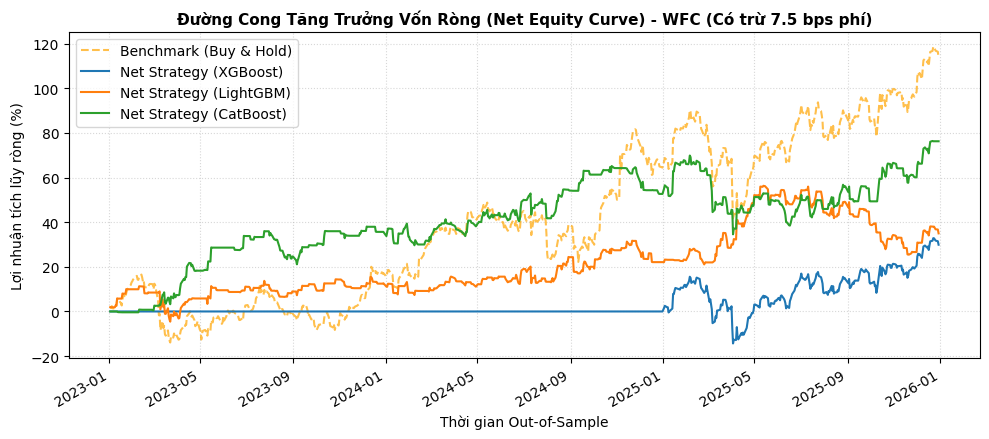


==================== ECONOMIC EVALUATION: BAC ====================
(Áp dụng Chi phí ma sát: 7.5 bps | Tính Sharpe tích hợp chuỗi EFFR thực tế)

▶ MÔ HÌNH: XGBoost
------------------------------------------------------------------------------------------
                  Regime  Days  Net Cum Ret (%)  Ann Ret (%)  Sharpe (EFFR)  Max DD (%)  Win Rate (%)  Turnover (%)
        Low VIX (<14.91)   247            18.88        19.30         0.9003      -12.49         48.65          0.81
Normal VIX (14.91-17.87)   254             2.83         2.81        -0.0166      -17.59         50.00          0.79
       High VIX (>17.87)   250             0.61         0.61         0.0192      -36.72         55.56          0.80
------------------------------------------------------------------------------------------

▶ MÔ HÌNH: LightGBM
------------------------------------------------------------------------------------------
                  Regime  Days  Net Cum Ret (%)  Ann Ret (%)  Sharpe (EFFR)  M

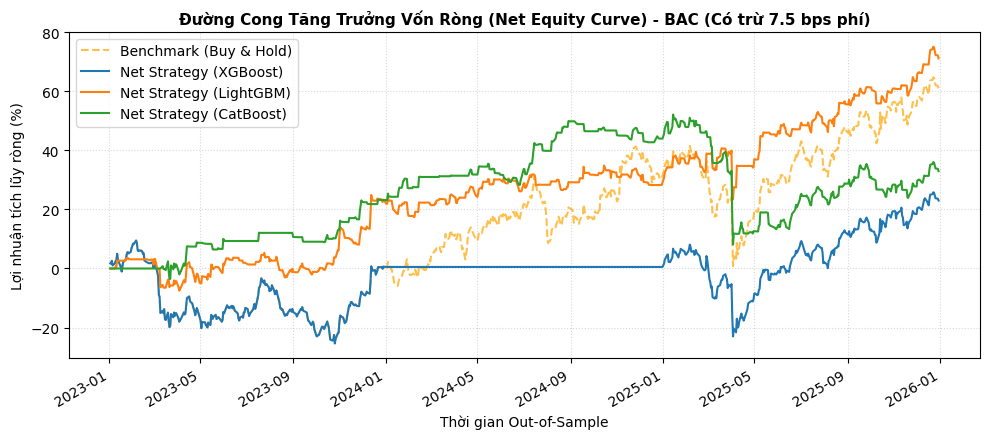

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("==========================================================================================")
print(" KHỞI CHẠY BƯỚC 3: ECONOMIC EVALUATION - NÂNG CẤP TRANSACTION COST & EFFR SHARPE")
print("==========================================================================================")

tickers = ["JPM", "WFC", "BAC"]
models = ["XGBoost", "LightGBM", "CatBoost"]
test_years = [2023, 2024, 2025]

# CẤU HÌNH CHI PHÍ GIAO DỊCH (7.5 bps = 0.00075 cho mỗi lần đảo vị thế)
TC_BPS = 7.5
TRANSACTION_COST = TC_BPS / 10000

for ticker in tickers:
    if ticker not in all_results_master or ticker not in all_dfs_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]
    results_single = all_results_master[ticker]

    # 1. Đồng bộ chuỗi dữ liệu Out-of-Sample
    test_full_mask = df_single["Date"].dt.year.isin(test_years)
    df_oos_full = df_single.loc[test_full_mask].reset_index(drop=True)
    dates_oos = df_oos_full["Date"]

    # 2. Xử lý Lại suất phi rủi ro EFFR (Đổi từ % năm sang tỷ lệ ngày: EFFR / 100 / 252)
    effr_cols = [c for c in df_single.columns if "EFFR" in c.upper()]
    if effr_cols:
        # Giả định nếu có cột gốc EFFR dạng số phần trăm nền (ví dụ: 5.25), chia cho 25200 để ra tỷ lệ ngày
        daily_rf = df_oos_full[effr_cols[0]].values / 25200
    else:
        # Nếu không tìm thấy cột EFFR, sử dụng mức nền trung bình 4.5% năm của giai đoạn 2023-2025 làm fallback
        daily_rf = np.full(len(df_oos_full), 4.5 / 25200)

    # 3. Dò tìm và phân tách Regime VIX theo phân vị
    vix_cols = [c for c in features_single if "VIX" in c.upper()]
    if not vix_cols:
        print(f"⚠️ Không tìm thấy feature VIX cho {ticker}. Bỏ qua phân tách regime...")
        continue

    vix_values = df_oos_full[vix_cols[0]].values
    q33 = np.quantile(vix_values, 1/3)
    q66 = np.quantile(vix_values, 2/3)

    regimes = {
        f"Low VIX (<{q33:.2f})": vix_values < q33,
        f"Normal VIX ({q33:.2f}-{q66:.2f})": (vix_values >= q33) & (vix_values <= q66),
        f"High VIX (>{q66:.2f})": vix_values > q66
    }

    print(f"\n==================== ECONOMIC EVALUATION: {ticker} ====================")
    print(f"(Áp dụng Chi phí ma sát: {TC_BPS} bps | Tính Sharpe tích hợp chuỗi EFFR thực tế)")

    # Lưu trữ các chuỗi lợi nhuận ròng để vẽ đồ thị tổng thể ở cuối
    net_strat_returns_all_models = {}

    # Duyệt qua từng mô hình học máy
    for model_name in models:
        actuals = np.array(results_single[model_name]["actuals"])
        preds = np.array(results_single[model_name]["preds"])

        # Tạo tín hiệu giao dịch dựa trên ngưỡng Mean động
        mean_threshold = np.mean(preds)
        signals = np.where(preds > mean_threshold, 1, 0)

        # Lợi nhuận thô (Chưa trừ phí)
        gross_strat_returns = signals * actuals

        # TÍNH TOÁN CHI PHÍ MA SÁT GIAO DỊCH THỰC TẾ TRÊN TỪNG PHIÊN
        # Xác định các điểm thay đổi vị thế: Ngày đầu tiên mở vị thế + các ngày thay đổi trạng thái
        trades = np.abs(np.diff(signals))
        trade_costs = np.zeros(len(signals))
        trade_costs[1:] = trades * TRANSACTION_COST
        if signals[0] == 1:
            trade_costs[0] = TRANSACTION_COST # Tính phí cho phiên mở lệnh Long đầu tiên trong tập dữ liệu

        # Lợi nhuận ròng thực tế sau khi trừ chi phí ma sát
        net_strat_returns = gross_strat_returns - trade_costs
        net_strat_returns_all_models[model_name] = net_strat_returns

        econ_regime_report = []

        # Phân tích hiệu quả kinh tế trên từng môi trường VIX
        for r_name, mask in regimes.items():
            r_actuals = actuals[mask]
            r_net_returns = net_strat_returns[mask]
            r_signals = signals[mask]
            r_daily_rf = daily_rf[mask]

            if len(r_actuals) == 0:
                continue

            # 1. Lợi nhuận tích lũy ròng (Net Cumulative Return)
            r_cum_strat = (1 + r_net_returns).cumprod() - 1
            final_cum_ret = r_cum_strat[-1] if len(r_cum_strat) > 0 else 0

            # 2. Lợi nhuận chuẩn hóa năm (Annualized Return)
            n_days = len(r_actuals)
            ann_ret = (1 + final_cum_ret) ** (252 / n_days) - 1 if final_cum_ret > -1 else -1

            # 3. Hệ số Sharpe Ratio chuẩn (Trừ chuỗi Risk-Free Rate EFFR của chính Regime đó)
            excess_returns = r_net_returns - r_daily_rf
            daily_std = r_net_returns.std() # Độ lệch chuẩn tính trên tổng danh mục ròng của chiến lược
            sharpe = (excess_returns.mean() / daily_std) * np.sqrt(252) if daily_std != 0 else 0

            # 4. Sụt giảm tài sản tối đa ròng (Net Max Drawdown)
            if n_days > 1:
                equity_curve = pd.Series((1 + r_net_returns).cumprod())
                running_max = equity_curve.cummax()
                drawdown = (equity_curve - running_max) / running_max
                max_dd = drawdown.min()
            else:
                max_dd = 0

            # 5. Tỷ lệ chiến thắng thực tế
            active_trades = r_actuals[r_signals == 1]
            win_rate = np.mean(active_trades > 0) * 100 if len(active_trades) > 0 else 0

            # 6. Tần suất giao dịch (Turnover)
            pos_changes = np.sum(np.abs(np.diff(r_signals))) if len(r_signals) > 1 else 0
            turnover = pos_changes / n_days

            econ_regime_report.append({
                "Regime": r_name,
                "Days": n_days,
                "Net Cum Ret (%)": round(final_cum_ret * 100, 2),
                "Ann Ret (%)": round(ann_ret * 100, 2),
                "Sharpe (EFFR)": round(sharpe, 4),
                "Max DD (%)": round(max_dd * 100, 2),
                "Win Rate (%)": round(win_rate, 2),
                "Turnover (%)": round(turnover * 100, 2)
            })

        print(f"\n▶ MÔ HÌNH: {model_name}")
        print("-" * 90)
        print(pd.DataFrame(econ_regime_report).to_string(index=False))
        print("-" * 90)

    # 4. VẼ ĐỒ THỊ EQUITY CURVE RÒNG TỔNG THỂ ĐỂ ĐỐI CHIẾU TRỰC QUAN
    plt.figure(figsize=(10, 4.5))
    sample_actuals = np.array(results_single["LightGBM"]["actuals"])
    plt.plot(dates_oos, ((1 + sample_actuals).cumprod() - 1) * 100, label="Benchmark (Buy & Hold)", color="orange", linestyle="--", alpha=0.7)

    for model_name in models:
        plt.plot(dates_oos, ((1 + net_strat_returns_all_models[model_name]).cumprod() - 1) * 100, label=f"Net Strategy ({model_name})", linewidth=1.5)

    plt.title(f"Đường Cong Tăng Trưởng Vốn Ròng (Net Equity Curve) - {ticker} (Có trừ {TC_BPS} bps phí)", fontsize=11, fontweight="bold")
    plt.xlabel("Thời gian Out-of-Sample")
    plt.ylabel("Lợi nhuận tích lũy ròng (%)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()
    print("=" * 88)

#Train Economic model

In [ ]:
!pip install arch statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.0 MB/s eta 0:00:00


In [ ]:
import warnings
from arch import arch_model
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# CẤU HÌNH HỆ THỐNG VÀ DANH SÁCH TẬP DỮ LIỆU CHẠY 3 NGÂN HÀNG
datasets = [
    {"ticker": "JPM", "filename": "JPM_master_arimax.csv"},
    {"ticker": "WFC", "filename": "WFC_master_arimax.csv"},
    {"ticker": "BAC", "filename": "BAC_master_arimax.csv"},
]

target_col = "target_return"
exog_cols = [
    "lag_return_1",
    "SPX_return_lag1",
    "VIX_return_lag1",
    "EFFR_change_lag1",
    "Yield_Spread_diff1_lag1",
]
test_years = [2023, 2024, 2025]

# Thùng chứa kết quả Kinh tế lượng toàn cục phục vụ cho bước so sánh cuối cùng
econometric_master_results = {}

print("=== BẮT ĐẦU CHẠY PIPELINE MÔ HÌNH KINH TẾ LƯỢNG (ECONOMETRIC BASELINES) ===")

# =====================================================================
# VÒNG LẶP CHÍNH DUYỆT QUA TỪNG NGÂN HÀNG
# =====================================================================
for dataset in datasets:
    ticker = dataset["ticker"]
    filename = dataset["filename"]

    print("\n" + "="*90)
    print(f" ⏳ KHỞI CHẠY KHỐI KINH TẾ LƯỢNG CHO NGÂN HÀNG: {ticker} (File: {filename})")
    print("="*90)

    try:
        # 1. Đọc và tiền xử lý dữ liệu chuỗi thời gian dùng chung
        df_econ = pd.read_csv(filename)
        df_econ["Date"] = pd.to_datetime(df_econ["Date"])
        df_econ = df_econ.sort_values("Date").reset_index(drop=True)
    except FileNotFoundError:
        print(f" Không tìm thấy file {filename}. Bỏ qua ngân hàng {ticker}.")
        continue

    # Thiết lập cấu trúc lưu trữ cục bộ cho ngân hàng hiện tại
    results = {
        "ARIMAX": {"preds": [], "actuals": []},
        "ARMA-GARCH": {"preds": [], "actuals": [], "vols": []},
    }

    years = df_econ["Date"].dt.year

    # 2. VÒNG LẶP WALK-FORWARD VALIDATION TỪNG NĂM
    for test_yr in test_years:
        print(f"  ▶ Đang xử lý khối kiểm thử dữ liệu năm: {test_yr}")

        train_mask = (years >= 2020) & (years < test_yr)
        test_mask = years == test_yr

        df_train_base = df_econ.loc[train_mask].reset_index(drop=True)
        df_test_year = df_econ.loc[test_mask].reset_index(drop=True)

        y_train = df_train_base[target_col].values
        X_train_df = df_train_base[exog_cols]
        X_train_np = X_train_df.values

        y_test = df_test_year[target_col].values
        X_test_df = df_test_year[exog_cols]
        X_test_np = X_test_df.values

        # --- MODEL 1: ARIMAX ---
        model_arimax = ARIMA(endog=y_train, exog=X_train_np, order=(1, 0, 0))
        fit_arimax = model_arimax.fit()
        preds_arimax = fit_arimax.forecast(steps=len(y_test), exog=X_test_np)

        results["ARIMAX"]["preds"].extend(preds_arimax)
        results["ARIMAX"]["actuals"].extend(y_test)

        # Áp dụng ngưỡng động (Mean) để tính toán hướng đi thực tế cho từng Fold
        threshold_arimax = np.mean(preds_arimax)
        acc_arimax = np.mean(np.where(y_test > 0, 1, 0) == np.where(preds_arimax > threshold_arimax, 1, 0)) * 100

        # --- MODEL 2: ARMA-GARCH ---
        y_combined = pd.concat([df_train_base[target_col], df_test_year[target_col]], ignore_index=True)
        X_combined = pd.concat([X_train_df, X_test_df], ignore_index=True)
        train_len = len(df_train_base)
        test_len = len(df_test_year)

        scale_factor = 100.0
        y_combined_scaled = y_combined * scale_factor

        model_garch = arch_model(y_combined_scaled, x=X_combined, mean="ARX", lags=0, vol="GARCH", p=1, q=1, dist="StudentsT", rescale=False)
        fit_garch = model_garch.fit(last_obs=train_len, disp="off", options={"method": "L-BFGS-B", "max_iter": 1000})

        x_forecast_dict = {col: X_test_df[col].values.reshape(test_len, 1) for col in exog_cols}
        forecasts = fit_garch.forecast(start=train_len, align="target", method="analytic", x=x_forecast_dict)

        fold_garch_preds = forecasts.mean.dropna().values.flatten() / scale_factor
        fold_garch_vols = np.sqrt(forecasts.variance.dropna().values.flatten()) / scale_factor

        # Align y_test với độ dài thực tế nhận được của GARCH dự báo
        actuals_aligned = y_test[:len(fold_garch_preds)]

        results["ARMA-GARCH"]["preds"].extend(fold_garch_preds)
        results["ARMA-GARCH"]["actuals"].extend(actuals_aligned)
        results["ARMA-GARCH"]["vols"].extend(fold_garch_vols)

        threshold_garch = np.mean(fold_garch_preds)
        acc_garch = np.mean(np.where(actuals_aligned > 0, 1, 0) == np.where(fold_garch_preds > threshold_garch, 1, 0)) * 100

        print(f"    ↳ [Accuracy] ARIMAX: {acc_arimax:.2f}% | ARMA-GARCH: {acc_garch:.2f}%")
        print(f"    ↳ [Mean Vol] ARMA-GARCH: {np.mean(fold_garch_vols):.6f}")

    # Đóng gói mảng kết quả của Ngân hàng hiện tại vào Master Dictionary toàn cục
    econometric_master_results[ticker] = results

    # 3. BÁO CÁO HIỆU SUẤT TỔNG THỂ OUT-OF-SAMPLE CHO NGÂN HÀNG HIỆN TẠI
    econ_report = []
    for m_name, data in results.items():
        actuals = np.array(data["actuals"])
        preds = np.array(data["preds"])

        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mae = mean_absolute_error(actuals, preds)

        # [CẢI TIẾN CHUẨN QUANT] Áp dụng ngưỡng Mean động tổng thể của mảng dự báo để loại bỏ bias thị trường một chiều
        overall_threshold = np.mean(preds)
        acc = np.mean(np.where(actuals > 0, 1, 0) == np.where(preds > overall_threshold, 1, 0)) * 100

        econ_report.append({
            "Model Baseline": m_name,
            "Overall RMSE": round(rmse, 5),
            "Overall MAE": round(mae, 5),
            "Directional Accuracy (%)": round(acc, 2)
        })

    report_df = pd.DataFrame(econ_report)
    print("\n" + "-" * 75)
    print(f"BẢNG HIỆU SUẤT TỔNG THỂ KHỐI KINH TẾ LƯỢNG - {ticker} (2023-2025)")
    print("-" * 75)
    print(report_df.to_string(index=False))
    print("-" * 75)

print("\n" + "="*90)
print("PIPELINE KINH TẾ LƯỢNG (ARIMAX & ARMA-GARCH) CHO CẢ 3 NGÂN HÀNG ĐÃ HOÀN TẤT TỰ ĐỘNG!")
print("="*90)

=== BẮT ĐẦU CHẠY PIPELINE MÔ HÌNH KINH TẾ LƯỢNG (ECONOMETRIC BASELINES) ===

 ⏳ KHỞI CHẠY KHỐI KINH TẾ LƯỢNG CHO NGÂN HÀNG: JPM (File: JPM_master_arimax.csv)
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2023
    ↳ [Accuracy] ARIMAX: 47.60% | ARMA-GARCH: 49.80%
    ↳ [Mean Vol] ARMA-GARCH: 0.015220
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2024
    ↳ [Accuracy] ARIMAX: 47.22% | ARMA-GARCH: 49.40%
    ↳ [Mean Vol] ARMA-GARCH: 0.014987
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2025
    ↳ [Accuracy] ARIMAX: 53.41% | ARMA-GARCH: 48.79%
    ↳ [Mean Vol] ARMA-GARCH: 0.015946

---------------------------------------------------------------------------
BẢNG HIỆU SUẤT TỔNG THỂ KHỐI KINH TẾ LƯỢNG - JPM (2023-2025)
---------------------------------------------------------------------------
Model Baseline  Overall RMSE  Overall MAE  Directional Accuracy (%)
        ARIMAX       0.01459      0.01002                     48.87
    ARMA-GARCH       0.01457      0.00997                     49.47
----------

#Train Elastic Net

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# CẤU HÌNH HỆ THỐNG VÀ DANH SÁCH TẬP DỮ LIỆU CHẠY 3 NGÂN HÀNG
# =====================================================================
datasets = [
    {"ticker": "JPM", "filename": "JPM_master_trees_updated.csv"},
    {"ticker": "WFC", "filename": "WFC_master_trees_updated.csv"},
    {"ticker": "BAC", "filename": "BAC_master_trees_updated.csv"},
]

exclude_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'target_return', 'target_direction']
target_reg = 'target_return'
test_years = [2023, 2024, 2025]

# Thùng chứa kết quả Elastic Net toàn cục (nếu bạn cần dùng cho bước so sánh cuối cùng)
elastic_net_master_results = {}

# =====================================================================
# VÒNG LẶP CHÍNH DUYỆT QUA TỪNG NGÂN HÀNG
# =====================================================================
for dataset in datasets:
    ticker = dataset["ticker"]
    filename = dataset["filename"]

    print("\n" + "="*90)
    print(f" KHỞI CHẠY PIPELINE ELASTIC NET CHO NGÂN HÀNG: {ticker} (File: {filename})")
    print("="*90)

    try:
        # 1. Đọc và chuẩn hóa cấu trúc dữ liệu chuỗi thời gian
        df_en = pd.read_csv(filename)
        df_en['Date'] = pd.to_datetime(df_en['Date'])
        df_en = df_en.sort_values('Date').reset_index(drop=True)
    except FileNotFoundError:
        print(f"Không tìm thấy file {filename}. Bỏ qua ngân hàng {ticker}.")
        continue

    # 2. Phân tách danh sách Features và Targets độc lập theo từng file
    features = [c for c in df_en.columns if c not in exclude_cols]
    years = df_en['Date'].dt.year

    all_predictions = []
    all_actuals = []

    print(f"Số lượng Features ghi nhận: {len(features)}")

    # 3. VÒNG LẶP WALK-FORWARD VALIDATION TỪNG NĂM
    for test_yr in test_years:
        print(f"  ▶ Đang xử lý Fold kiểm thử cho năm: {test_yr}")

        # Cấu hình Expanding Window
        train_mask = (years >= 2020) & (years < test_yr)
        test_mask = (years == test_yr)

        X_train = df_en.loc[train_mask, features].values
        y_train = df_en.loc[train_mask, target_reg].values

        X_test = df_en.loc[test_mask, features].values
        y_test = df_en.loc[test_mask, target_reg].values

        # Chuẩn hóa dữ liệu (Feature Scaling) - BẮT BUỘC đối với Elastic Net
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Khởi tạo và huấn luyện mô hình Elastic Net
        model = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=2000)
        model_fit = model.fit(X_train_scaled, y_train)

        # Dự báo Out-of-sample cho năm Test hiện tại
        predictions = model_fit.predict(X_test_scaled)

        all_predictions.extend(predictions)
        all_actuals.extend(y_test)

        # Đánh giá nhanh hiệu suất từng năm (Sử dụng ngưỡng động để tính Directional Acc chính xác hơn)
        fold_rmse = np.sqrt(mean_squared_error(y_test, predictions))
        fold_mae = mean_absolute_error(y_test, predictions)

        fold_threshold = np.mean(predictions)
        dir_actual = np.where(y_test > 0, 1, 0)
        dir_pred = np.where(predictions > fold_threshold, 1, 0)
        fold_acc = np.mean(dir_actual == dir_pred) * 100

        # Đếm số lượng feature được giữ lại (Hệ số gán alpha khác 0 nhờ cơ chế trừng phạt L1)
        active_features = np.sum(model_fit.coef_ != 0)

        print(f"    ➔ Kết quả {test_yr}: RMSE = {fold_rmse:.5f} | MAE = {fold_mae:.5f} | Directional Accuracy = {fold_acc:.2f}%")
        print(f"      ↳ Số lượng Features giữ lại thực tế: {active_features}/{len(features)}")

    # Lưu trữ kết quả dự báo 3 năm gộp của Ticker hiện tại vào Master Dict phục vụ so sánh sau này
    elastic_net_master_results[ticker] = {
        "preds": all_predictions,
        "actuals": all_actuals
    }

    # 4. BÁO CÁO HIỆU SUẤT TỔNG THỂ GIAI ĐOẠN OUT-OF-SAMPLE (2023 - 2025) CHO TỪNG TICKER
    overall_rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
    overall_mae = mean_absolute_error(all_actuals, all_predictions)

    overall_dir_actual = np.where(np.array(all_actuals) > 0, 1, 0)

    # [CẢI TIẾN QUAN TRỌNG] Sử dụng Mean Threshold tổng thể để triệt tiêu lỗi bias một chiều của mô hình tuyến tính
    overall_threshold = np.mean(all_predictions)
    overall_dir_pred = np.where(np.array(all_predictions) > overall_threshold, 1, 0)
    overall_acc = np.mean(overall_dir_actual == overall_dir_pred) * 100

    print("\n" + "-"*60)
    print(f"BÁO CÁO HIỆU SUẤT TỔNG THỂ ELASTIC NET - {ticker} (2023-2025)")
    print(f" • Overall RMSE: {overall_rmse:.5f}")
    print(f" • Overall MAE : {overall_mae:.5f}")
    print(f" • Overall Directional Accuracy: {overall_acc:.2f}%")
    print("-"*60 + "\n")

print("="*90)
print("PIPELINE HUẤN LUYỆN TỰ ĐỘNG ELASTIC NET CHO CẢ 3 NGÂN HÀNG ĐÃ HOÀN TẤT!")
print("="*90)


 KHỞI CHẠY PIPELINE ELASTIC NET CHO NGÂN HÀNG: JPM (File: JPM_master_trees_updated.csv)
Số lượng Features ghi nhận: 45
  ▶ Đang xử lý Fold kiểm thử cho năm: 2023
    ➔ Kết quả 2023: RMSE = 0.01319 | MAE = 0.00953 | Directional Accuracy = 48.00%
      ↳ Số lượng Features giữ lại thực tế: 19/45
  ▶ Đang xử lý Fold kiểm thử cho năm: 2024
    ➔ Kết quả 2024: RMSE = 0.01506 | MAE = 0.01006 | Directional Accuracy = 44.05%
      ↳ Số lượng Features giữ lại thực tế: 18/45
  ▶ Đang xử lý Fold kiểm thử cho năm: 2025
    ➔ Kết quả 2025: RMSE = 0.01584 | MAE = 0.01096 | Directional Accuracy = 51.41%
      ↳ Số lượng Features giữ lại thực tế: 17/45

------------------------------------------------------------
BÁO CÁO HIỆU SUẤT TỔNG THỂ ELASTIC NET - JPM (2023-2025)
 • Overall RMSE: 0.01474
 • Overall MAE : 0.01018
 • Overall Directional Accuracy: 49.53%
------------------------------------------------------------


 KHỞI CHẠY PIPELINE ELASTIC NET CHO NGÂN HÀNG: WFC (File: WFC_master_trees_updated.

#DM Test

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# =====================================================================
# 1. TỰ VIẾT HÀM KIỂM ĐỊNH DIEBOLD-MARIANO CHUẨN TOÁN HỌC
# =====================================================================
def diebold_mariano_test(actual, pred1, pred2, h=1):
    """
    Kiểm định Diebold-Mariano so sánh năng lực dự báo giữa 2 mô hình.
    Null Hypothesis (H0): Hai mô hình có sai số dự báo trung bình như nhau.
    Alternative Hypothesis (H1): Hai mô hình có năng lực dự báo khác nhau.

    Sử dụng hàm mất mát Bình phương sai số (Squared Error Loss).
    Tích hợp hiệu chỉnh Newey-West cho phương sai của chuỗi chênh lệch loss.
    """
    actual = np.array(actual)
    pred1 = np.array(pred1)
    pred2 = np.array(pred2)

    # Tính chuỗi Loss của từng mô hình (Squared Error)
    loss1 = (actual - pred1) ** 2
    loss2 = (actual - pred2) ** 2

    # Chuỗi chênh lệch Loss (d_t)
    d = loss1 - loss2
    d_mean = np.mean(d)
    T = len(d)

    # Tính toán Auto-covariance phục vụ hiệu chỉnh Newey-West (cho cấu trúc trễ h-1)
    # Với dự báo 1-bước-trước (h=1), cấu trúc trễ hiệu chỉnh tối ưu là h-1 = 0
    gamma = np.zeros(h)
    for lag in range(0, h):
        if lag == 0:
            gamma[lag] = np.var(d)
        else:
            gamma[lag] = np.mean((d[lag:] - d_mean) * (d[:-lag] - d_mean))

    # Tính phương sai tiệm cận (Asymptotic Variance)
    v = gamma[0] + 2 * np.sum([(1 - (k / h)) * gamma[k] for k in range(1, h)])

    if v <= 0:
        return 0.0, 1.0  # Tránh lỗi chia cho 0 hoặc căn bậc hai số âm

    # Thống kê kiểm định DM tuân theo phân phối chuẩn chuẩn hóa N(0, 1) khi T tiến ra vô cùng
    dm_stat = d_mean / np.sqrt(v / T)

    # Tính p-value (Two-tailed test)
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value


# =====================================================================
# 2. KHỞI CHẠY KIỂM ĐỊNH TRÊN TOÀN BỘ 6 MÔ HÌNH CHO 3 NGÂN HÀNG
# =====================================================================
print("==========================================================================================")
print("  STATISTICAL SIGNIFICANCE TEST (DIEBOLD-MARIANO TEST)")
print("==========================================================================================")

tickers = ["JPM", "WFC", "BAC"]
model_names_ordered = ["XGBoost", "LightGBM", "CatBoost", "ElasticNet", "ARIMAX", "ARMA-GARCH"]

for ticker in tickers:
    print("\n" + "=" * 90)
    print(f" 📊 MA TRẬN KIỂM ĐỊNH DIEBOLD-MARIANO CHO NGÂN HÀNG: {ticker}")
    print("=" * 90)
    print("Giải thích ký hiệu ý nghĩa thống kê ở mức alpha = 5%:")
    print(" 🟢 Model 2 TỐT HƠN Model 1 rõ rệt | 🔴 Model 2 KÉM HƠN Model 1 rõ rệt | ❌ Không có sự khác biệt")
    print("-" * 90)

    # Thu thập chuỗi dự báo và thực tế từ 3 nhóm Master Dictionaries độc lập
    raw_preds = {}
    raw_actuals = {}

    try:
        # Nhóm 1: Mô hình cây
        for m in ["XGBoost", "LightGBM", "CatBoost"]:
            raw_preds[m] = all_results_master[ticker][m]["preds"]
            raw_actuals[m] = all_results_master[ticker][m]["actuals"]

        # Nhóm 2: Elastic Net
        raw_preds["ElasticNet"] = elastic_net_master_results[ticker]["preds"]
        raw_actuals["ElasticNet"] = elastic_net_master_results[ticker]["actuals"]

        # Nhóm 3: Kinh tế lượng
        for m in ["ARIMAX", "ARMA-GARCH"]:
            raw_preds[m] = econometric_master_results[ticker][m]["preds"]
            raw_actuals[m] = econometric_master_results[ticker][m]["actuals"]
    except KeyError as e:
        print(f"❌ Lỗi: Không tìm thấy thùng chứa dữ liệu phù hợp. Vui lòng chạy lại pipeline chính. Chi tiết lỗi: {e}")
        continue

    # ĐỒNG BỘ HÓA ĐỘ DÀI: Cắt ngắn chuỗi theo chiều dài của mô hình ARMA-GARCH
    min_len = len(raw_preds["ARMA-GARCH"])

    aligned_preds = {m: np.array(raw_preds[m][:min_len]) for m in model_names_ordered}
    aligned_actuals = {m: np.array(raw_actuals[m][:min_len]) for m in model_names_ordered}

    # Lấy chuỗi actual chuẩn hóa (sử dụng chuỗi đã đồng bộ của bất kỳ mô hình nào)
    actual_series = aligned_actuals["ARMA-GARCH"]

    dm_report = []

    # Duyệt qua các cặp mô hình để so sánh chéo (Pairwise Comparison)
    for i in range(len(model_names_ordered)):
        for j in range(len(model_names_ordered)):
            if i == j:
                continue

            m1 = model_names_ordered[i]
            m2 = model_names_ordered[j]

            # Chạy hàm DM Test (h=1 cho dự báo 1 bước trước)
            dm_stat, p_val = diebold_mariano_test(actual_series, aligned_preds[m1], aligned_preds[m2], h=1)

            # Biện luận kết quả ý nghĩa thống kê
            if p_val < 0.05:
                # Nếu dm_stat > 0 nghĩa là Loss(Model 1) > Loss(Model 2) -> Model 2 có sai số nhỏ hơn -> Tốt hơn
                if dm_stat > 0:
                    status = "🟢 M2 Tốt hơn M1"
                else:
                    status = "🔴 M2 Kém hơn M1"
            else:
                status = "❌ Không khác biệt"

            dm_report.append({
                "Model 1 (M1)": m1,
                "Model 2 (M2)": m2,
                "DM Stat": round(dm_stat, 4),
                "p-value": round(p_val, 4),
                "Significance": status
            })

    # Chuyển đổi báo cáo sang DataFrame và in ra màn hình dạng bảng sạch sẽ
    df_dm_report = pd.DataFrame(dm_report)

    # Lọc hiển thị một số cặp đối chiếu cốt lõi giữa Machine Learning và Econometrics để tránh loãng bảng dữ liệu
    # Bạn có thể bỏ comment dòng dưới nếu muốn in ra toàn bộ ma trận so sánh chéo không lọc
    # print(df_dm_report.to_string(index=False))

    # Khuyến nghị: Chỉ in các cặp đối chiếu có tính chất phản biện giả thuyết cao (ML vs Baselines)
    core_comparisons = df_dm_report[
        df_dm_report["Model 1 (M1)"].isin(["ARIMAX", "ARMA-GARCH", "ElasticNet"]) &
        df_dm_report["Model 2 (M2)"].isin(["LightGBM", "CatBoost", "XGBoost"])
    ]
    print(core_comparisons.to_string(index=False))
    print("=" * 90)

  STATISTICAL SIGNIFICANCE TEST (DIEBOLD-MARIANO TEST)

 📊 MA TRẬN KIỂM ĐỊNH DIEBOLD-MARIANO CHO NGÂN HÀNG: JPM
Giải thích ký hiệu ý nghĩa thống kê ở mức alpha = 5%:
 🟢 Model 2 TỐT HƠN Model 1 rõ rệt | 🔴 Model 2 KÉM HƠN Model 1 rõ rệt | ❌ Không có sự khác biệt
------------------------------------------------------------------------------------------
Model 1 (M1) Model 2 (M2)  DM Stat  p-value      Significance
  ElasticNet      XGBoost   2.0545   0.0399   🟢 M2 Tốt hơn M1
  ElasticNet     LightGBM   1.4622   0.1437 ❌ Không khác biệt
  ElasticNet     CatBoost   0.6696   0.5031 ❌ Không khác biệt
      ARIMAX      XGBoost   1.1183   0.2634 ❌ Không khác biệt
      ARIMAX     LightGBM   0.7146   0.4749 ❌ Không khác biệt
      ARIMAX     CatBoost   0.0224   0.9821 ❌ Không khác biệt
  ARMA-GARCH      XGBoost   0.4096   0.6821 ❌ Không khác biệt
  ARMA-GARCH     LightGBM  -0.0025   0.9980 ❌ Không khác biệt
  ARMA-GARCH     CatBoost  -1.3162   0.1881 ❌ Không khác biệt

 📊 MA TRẬN KIỂM ĐỊNH DIEBOL

#Regime-Specific SHAP Analysis


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: JPM

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
         Feature  SHAP Importance
VIX_volatility_5         0.000552
   overnight_gap         0.000539
 VIX_return_lag1         0.000429
  VIX_momentum_5         0.000343
      VIX_return         0.000340
----------------------------------------------------------------------


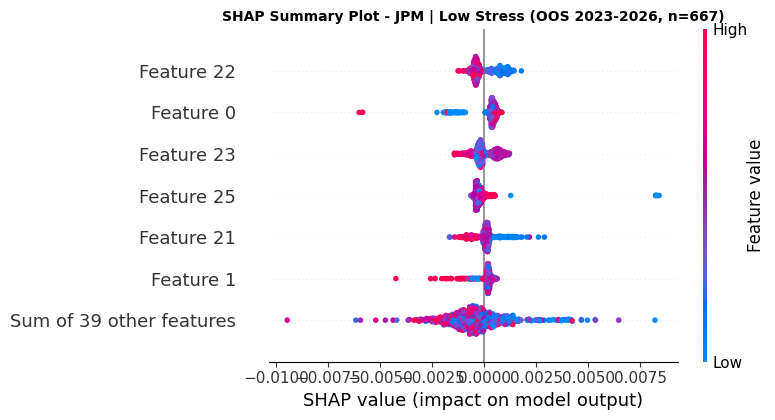


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
         Feature  SHAP Importance
   overnight_gap         0.000975
VIX_volatility_5         0.000618
 VIX_return_lag1         0.000568
       return_1d         0.000543
            MACD         0.000541
----------------------------------------------------------------------


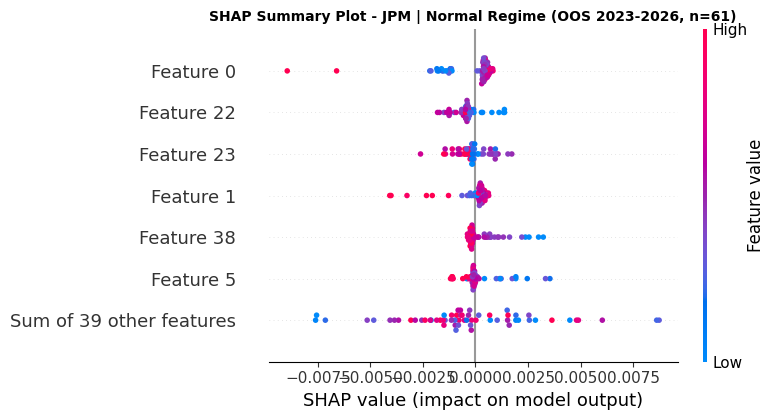


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
       Feature  SHAP Importance
VIX_momentum_5         0.001693
 volatility_20         0.001593
          MACD         0.001484
     VIX_Close         0.001234
 volatility_10         0.001118
----------------------------------------------------------------------


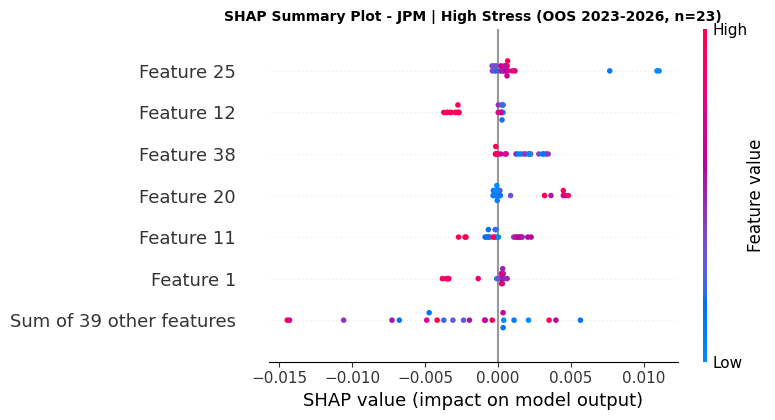


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: WFC

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
        Feature  SHAP Importance
           MACD         0.000421
   lag_return_3         0.000385
VIX_return_lag1         0.000342
    MACD_Signal         0.000300
   lag_return_2         0.000293
----------------------------------------------------------------------


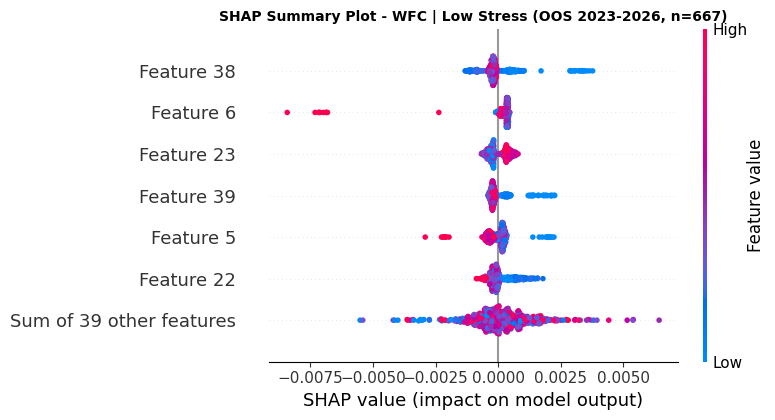


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
         Feature  SHAP Importance
            MACD         0.000990
    lag_return_1         0.000730
      XLF_return         0.000641
XLF_volatility_5         0.000555
    lag_return_2         0.000545
----------------------------------------------------------------------


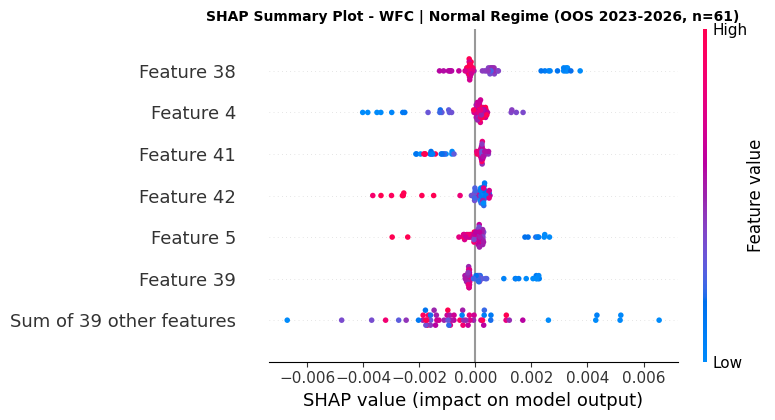


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
         Feature  SHAP Importance
            MACD         0.002387
    lag_return_1         0.001266
XLF_volatility_5         0.001210
     MACD_Signal         0.001185
   volatility_10         0.001161
----------------------------------------------------------------------


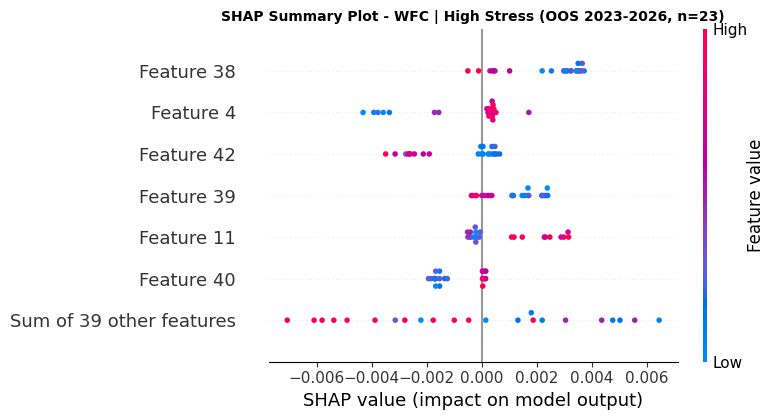


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: BAC

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
         Feature  SHAP Importance
   overnight_gap         0.000806
 Rolling_Beta_30         0.000573
VIX_volatility_5         0.000543
    volume_shock         0.000466
      VIX_return         0.000464
----------------------------------------------------------------------


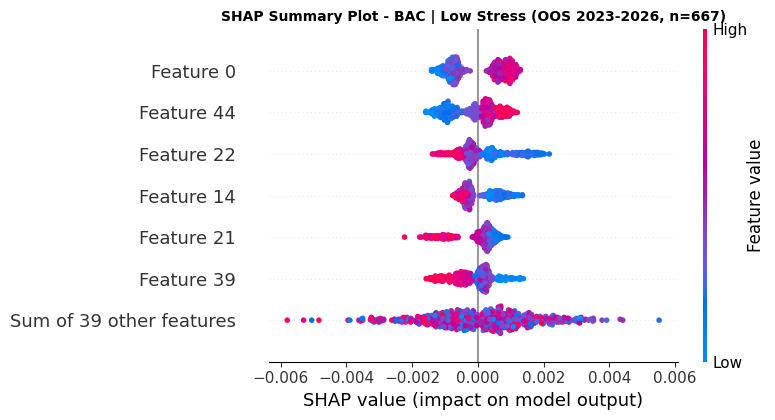


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
         Feature  SHAP Importance
   overnight_gap         0.000810
      VIX_return         0.000723
    lag_return_3         0.000660
VIX_volatility_5         0.000641
    volume_shock         0.000611
----------------------------------------------------------------------


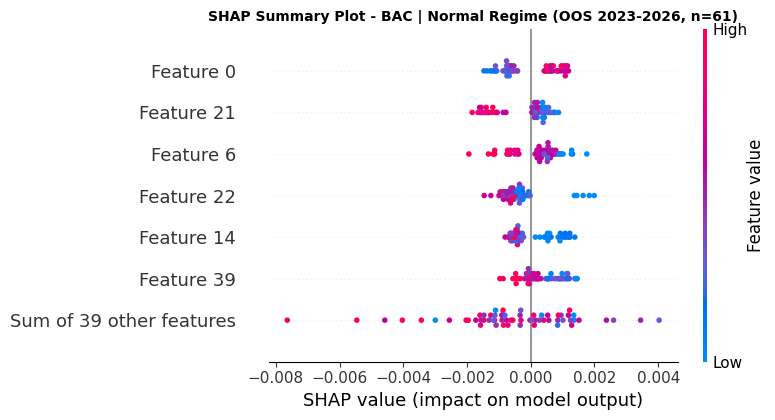


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
         Feature  SHAP Importance
      VIX_return         0.000974
       return_5d         0.000889
    lag_return_3         0.000857
VIX_volatility_5         0.000843
     MACD_Signal         0.000742
----------------------------------------------------------------------


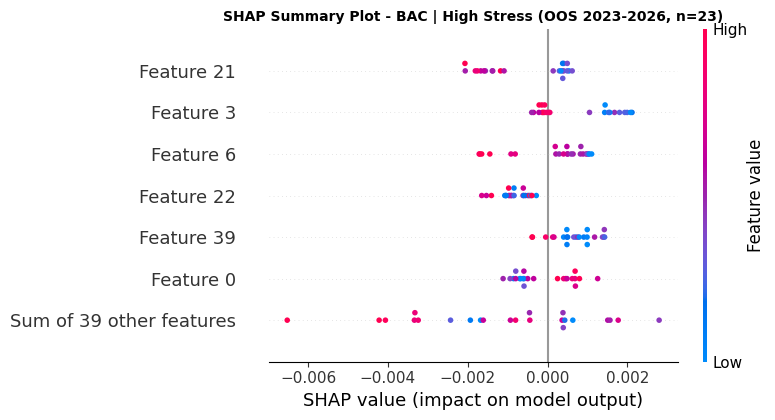

In [ ]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "LightGBM"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]
    years = df_single["Date"].dt.year

    # 1. Dò tìm chính xác cột biến động VIX
    vix_cols = [c for c in features_single if "VIX" in c.upper()]
    if not vix_cols:
        print(f"⚠️ Không tìm thấy feature VIX cho {ticker}. Bỏ qua...")
        continue
    vix_col_name = vix_cols[0]

    # 2. Xác định các chốt chặn Quantile từ tập TRAIN lịch sử (trước 2023) để chống Data Leakage
    train_mask = years < 2023
    vix_train_values = df_single.loc[train_mask, vix_col_name].values
    q33_train = np.quantile(vix_train_values, 1 / 3)
    q66_train = np.quantile(vix_train_values, 2 / 3)

    # 3. Lọc toàn bộ tập dữ liệu kiểm thử Out-of-Sample (OOS: 2023 - 2026)
    oos_mask = (years >= 2023) & (years <= 2026)
    df_oos = df_single.loc[oos_mask].reset_index(drop=True)

    if df_oos.empty:
        print(
            f"⚠️ Không có dữ liệu OOS (2023-2026) cho {ticker}. Bỏ qua..."
        )
        continue

    X_test_snapshot = df_oos[features_single].values
    vix_test_values = df_oos[vix_col_name].values

    # 4. Tính toán SHAP tổng thể cho toàn bộ giai đoạn OOS (2023-2026)
    current_model = fitted_models[TARGET_MODEL_NAME][ticker]
    explainer = shap.TreeExplainer(current_model)
    shap_vals_global = explainer(X_test_snapshot)

    # 5. Phân tách mặt nạ (masks) cho 3 vùng Stress dựa trên ngưỡng Train
    regime_masks = {
        "Low Stress": vix_test_values < q33_train,
        "Normal Regime": (vix_test_values >= q33_train)
        & (vix_test_values <= q66_train),
        "High Stress": vix_test_values > q66_train,
    }

    print("\n" + "=" * 90)
    print(
        f" PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: {ticker}"
    )
    print("=" * 90)

    # Duyệt qua từng vùng cấu trúc thị trường độc lập
    for r_name, r_mask in regime_masks.items():
        n_samples = np.sum(r_mask)
        if n_samples == 0:
            print(
                f"\nTrạng thái [{r_name}] không có ngày giao dịch nào trong giai đoạn OOS (2023-2026)."
            )
            continue

        # Trích xuất phần dữ liệu SHAP tương ứng với Regime hiện tại
        shap_vals_regime = copy.deepcopy(shap_vals_global[r_mask])

        # Tính toán Importance cục bộ (Mean Absolute SHAP)
        shap_importance_regime = np.abs(shap_vals_regime.values).mean(
            axis=0
        )

        importance_df = pd.DataFrame({
            "Feature": features_single,
            "SHAP Importance": np.round(shap_importance_regime, 6),
        }).sort_values(by="SHAP Importance", ascending=False).reset_index(
            drop=True
        )

        print(
            f"\nTOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [{r_name.upper()}] ({n_samples} ngày OOS)"
        )
        print("-" * 70)
        print(importance_df.head(5).to_string(index=False))
        print("-" * 70)

        # 6. Vẽ biểu đồ trực quan Beeswarm cục bộ cho Regime
        plt.figure(figsize=(8.5, 3.5))
        shap.plots.beeswarm(shap_vals_regime, max_display=7, show=False)
        plt.title(
            f"SHAP Summary Plot - {ticker} | {r_name} (OOS 2023-2026, n={n_samples})",
            fontsize=10,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

    print("=" * 90)


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: JPM

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


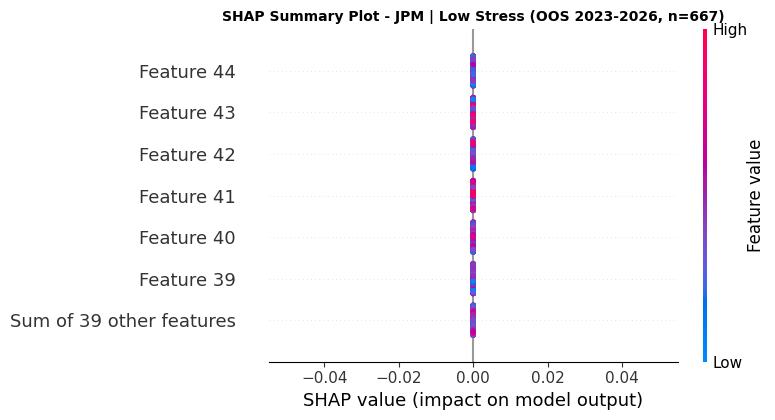


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


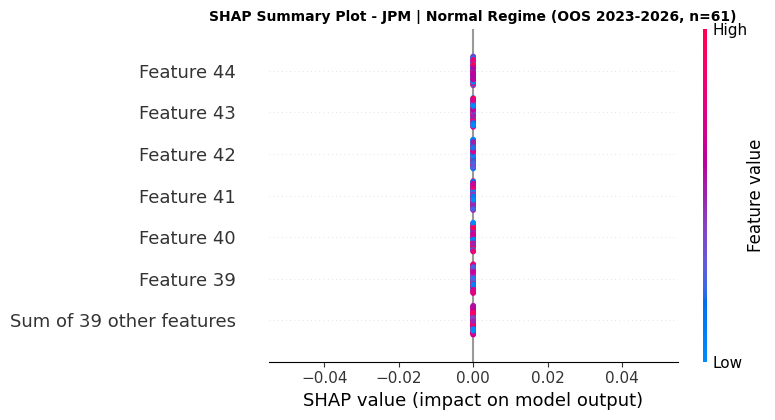


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


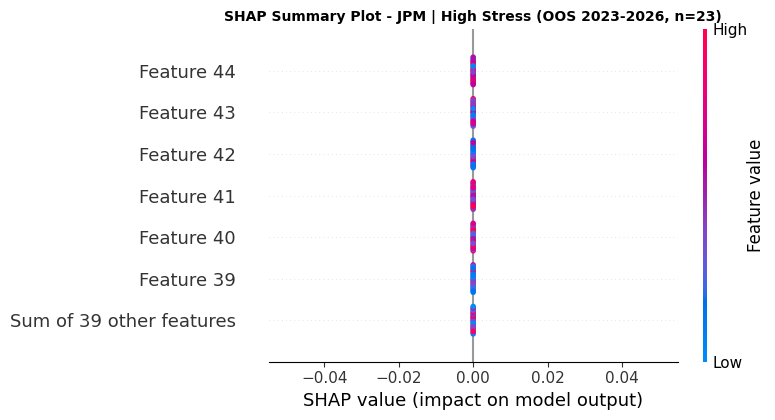


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: WFC

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


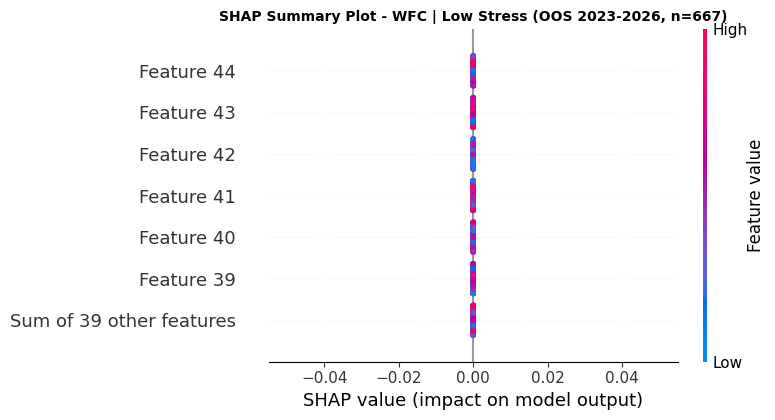


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


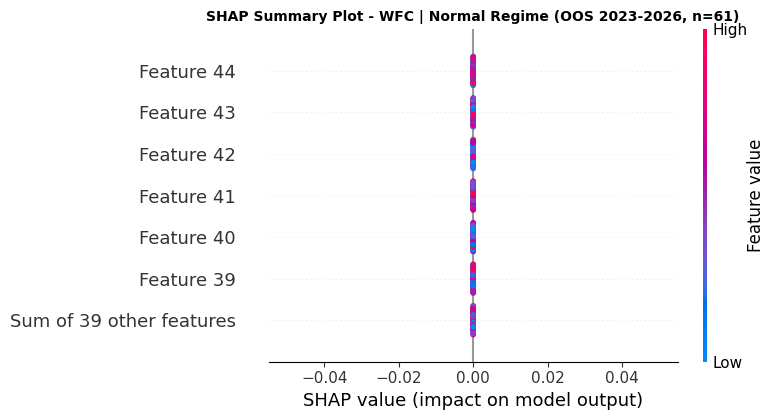


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


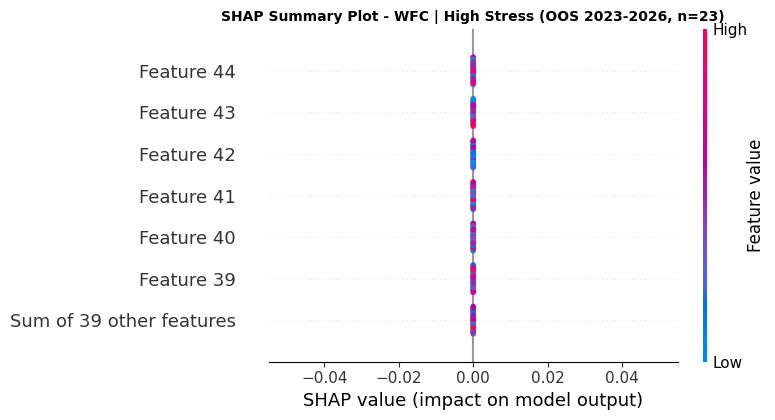


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: BAC

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


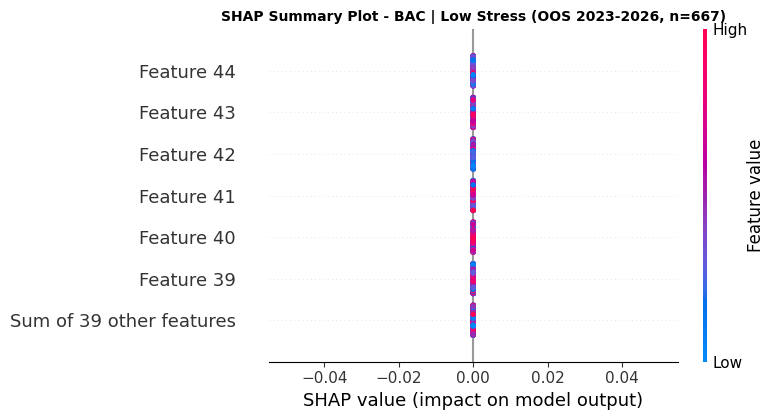


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


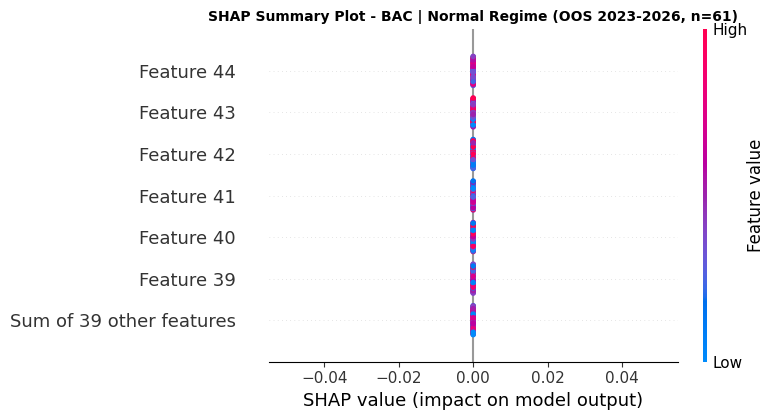


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
      Feature  SHAP Importance
overnight_gap              0.0
    return_1d              0.0
    return_3d              0.0
    return_5d              0.0
 lag_return_1              0.0
----------------------------------------------------------------------


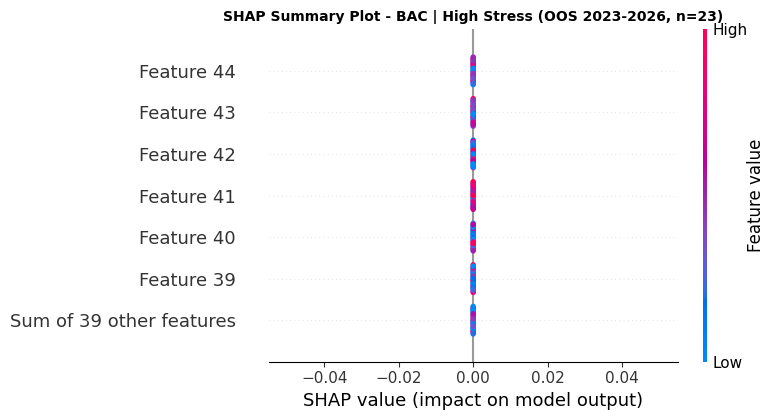

In [ ]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "XGBoost"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]
    years = df_single["Date"].dt.year

    # 1. Dò tìm chính xác cột biến động VIX
    vix_cols = [c for c in features_single if "VIX" in c.upper()]
    if not vix_cols:
        print(f"⚠️ Không tìm thấy feature VIX cho {ticker}. Bỏ qua...")
        continue
    vix_col_name = vix_cols[0]

    # 2. Xác định các chốt chặn Quantile từ tập TRAIN lịch sử (trước 2023) để chống Data Leakage
    train_mask = years < 2023
    vix_train_values = df_single.loc[train_mask, vix_col_name].values
    q33_train = np.quantile(vix_train_values, 1 / 3)
    q66_train = np.quantile(vix_train_values, 2 / 3)

    # 3. Lọc toàn bộ tập dữ liệu kiểm thử Out-of-Sample (OOS: 2023 - 2026)
    oos_mask = (years >= 2023) & (years <= 2026)
    df_oos = df_single.loc[oos_mask].reset_index(drop=True)

    if df_oos.empty:
        print(
            f"⚠️ Không có dữ liệu OOS (2023-2026) cho {ticker}. Bỏ qua..."
        )
        continue

    X_test_snapshot = df_oos[features_single].values
    vix_test_values = df_oos[vix_col_name].values

    # 4. Tính toán SHAP tổng thể cho toàn bộ giai đoạn OOS (2023-2026)
    current_model = fitted_models[TARGET_MODEL_NAME][ticker]
    explainer = shap.TreeExplainer(current_model)
    shap_vals_global = explainer(X_test_snapshot)

    # 5. Phân tách mặt nạ (masks) cho 3 vùng Stress dựa trên ngưỡng Train
    regime_masks = {
        "Low Stress": vix_test_values < q33_train,
        "Normal Regime": (vix_test_values >= q33_train)
        & (vix_test_values <= q66_train),
        "High Stress": vix_test_values > q66_train,
    }

    print("\n" + "=" * 90)
    print(
        f" PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: {ticker}"
    )
    print("=" * 90)

    # Duyệt qua từng vùng cấu trúc thị trường độc lập
    for r_name, r_mask in regime_masks.items():
        n_samples = np.sum(r_mask)
        if n_samples == 0:
            print(
                f"\nTrạng thái [{r_name}] không có ngày giao dịch nào trong giai đoạn OOS (2023-2026)."
            )
            continue

        # Trích xuất phần dữ liệu SHAP tương ứng với Regime hiện tại
        shap_vals_regime = copy.deepcopy(shap_vals_global[r_mask])

        # Tính toán Importance cục bộ (Mean Absolute SHAP)
        shap_importance_regime = np.abs(shap_vals_regime.values).mean(
            axis=0
        )

        importance_df = pd.DataFrame({
            "Feature": features_single,
            "SHAP Importance": np.round(shap_importance_regime, 6),
        }).sort_values(by="SHAP Importance", ascending=False).reset_index(
            drop=True
        )

        print(
            f"\nTOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [{r_name.upper()}] ({n_samples} ngày OOS)"
        )
        print("-" * 70)
        print(importance_df.head(5).to_string(index=False))
        print("-" * 70)

        # 6. Vẽ biểu đồ trực quan Beeswarm cục bộ cho Regime
        plt.figure(figsize=(8.5, 3.5))
        shap.plots.beeswarm(shap_vals_regime, max_display=7, show=False)
        plt.title(
            f"SHAP Summary Plot - {ticker} | {r_name} (OOS 2023-2026, n={n_samples})",
            fontsize=10,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

    print("=" * 90)


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: JPM

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
          Feature  SHAP Importance
   VIX_momentum_5         0.000204
       SPX_return         0.000054
       VIX_return         0.000052
     volatility_5         0.000029
SPX_volatility_20         0.000027
----------------------------------------------------------------------


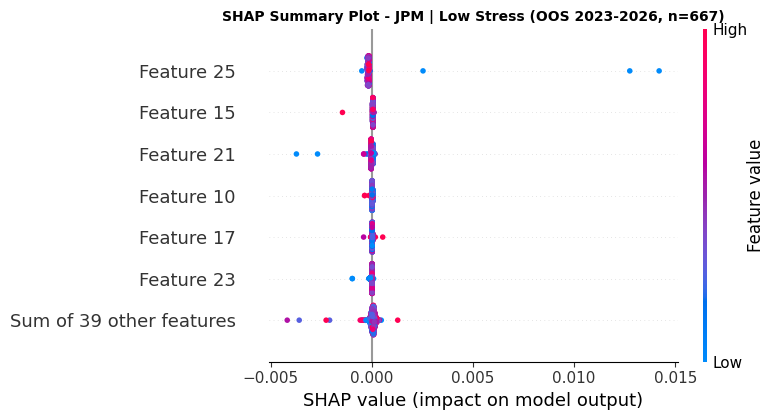


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
       Feature  SHAP Importance
VIX_momentum_5         0.000183
    SPX_return         0.000072
    VIX_return         0.000063
  volatility_5         0.000052
     return_5d         0.000043
----------------------------------------------------------------------


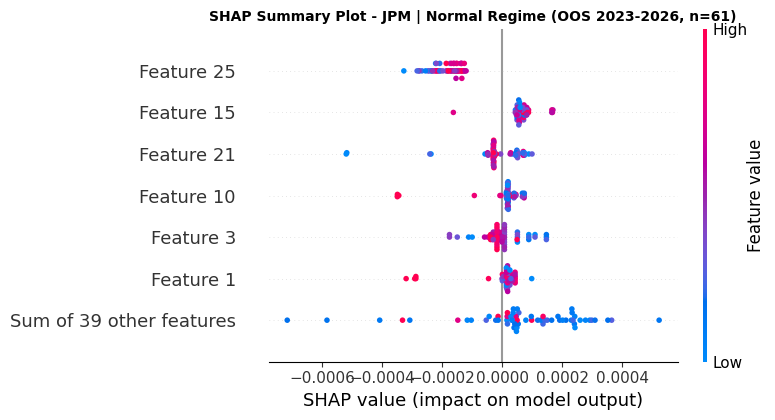


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
          Feature  SHAP Importance
   VIX_momentum_5         0.002217
       SPX_return         0.000626
       VIX_return         0.000376
SPX_volatility_20         0.000250
     lag_return_1         0.000234
----------------------------------------------------------------------


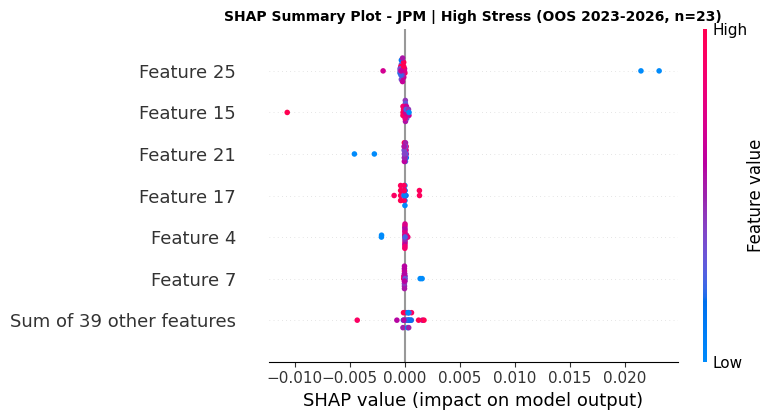


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: WFC

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
       Feature  SHAP Importance
VIX_momentum_5         0.000200
          MACD         0.000135
 volatility_20         0.000120
  lag_return_2         0.000105
    VIX_return         0.000103
----------------------------------------------------------------------


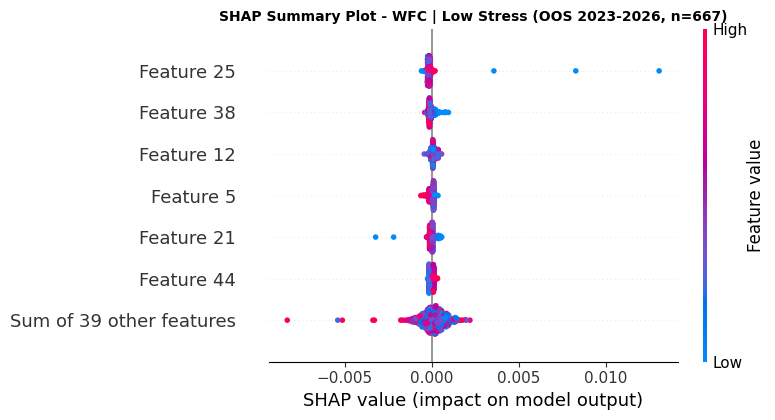


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
        Feature  SHAP Importance
           MACD         0.000212
 VIX_momentum_5         0.000206
price_ma5_ratio         0.000157
   lag_return_2         0.000148
     XLF_return         0.000139
----------------------------------------------------------------------


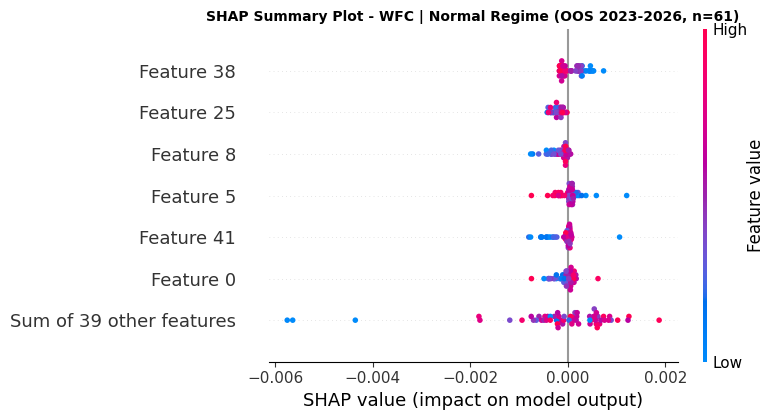


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
        Feature  SHAP Importance
 VIX_momentum_5         0.002048
price_ma5_ratio         0.000482
   lag_return_3         0.000406
     VIX_return         0.000406
           MACD         0.000388
----------------------------------------------------------------------


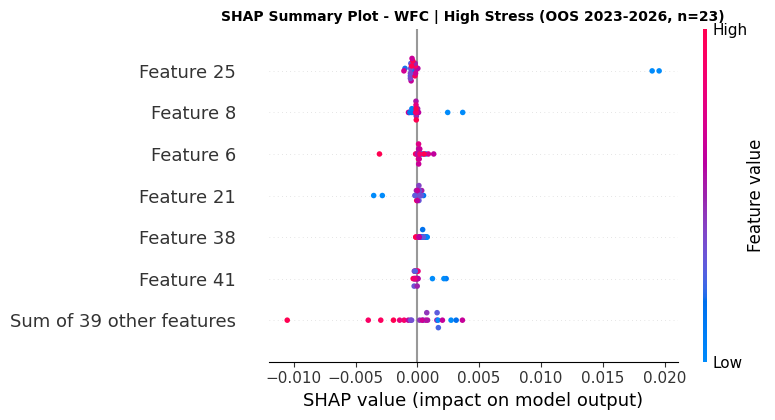


 PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: BAC

TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [LOW STRESS] (667 ngày OOS)
----------------------------------------------------------------------
       Feature  SHAP Importance
VIX_momentum_5         0.000138
    VIX_return         0.000100
     return_3d         0.000057
    XLF_return         0.000048
     return_1d         0.000041
----------------------------------------------------------------------


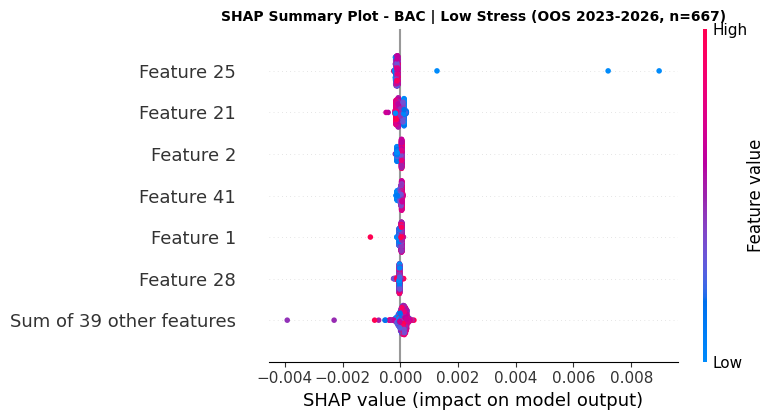


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [NORMAL REGIME] (61 ngày OOS)
----------------------------------------------------------------------
       Feature  SHAP Importance
VIX_momentum_5         0.000152
    VIX_return         0.000118
     return_3d         0.000066
    XLF_return         0.000061
          DGS2         0.000048
----------------------------------------------------------------------


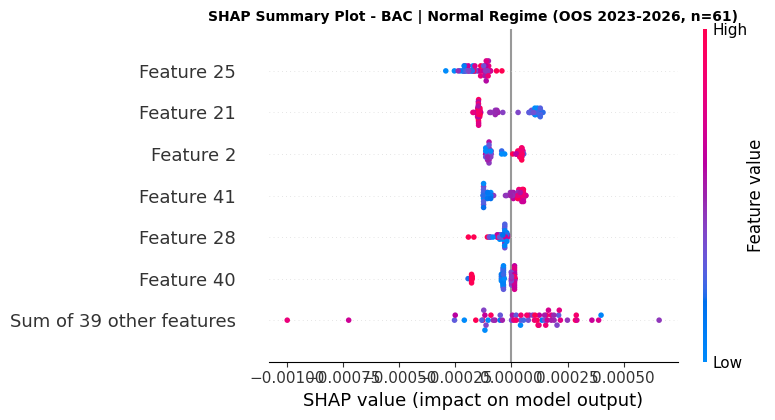


TOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [HIGH STRESS] (23 ngày OOS)
----------------------------------------------------------------------
         Feature  SHAP Importance
  VIX_momentum_5         0.001546
 price_ma5_ratio         0.000414
      SPX_return         0.000187
       VIX_Close         0.000181
VIX_volatility_5         0.000171
----------------------------------------------------------------------


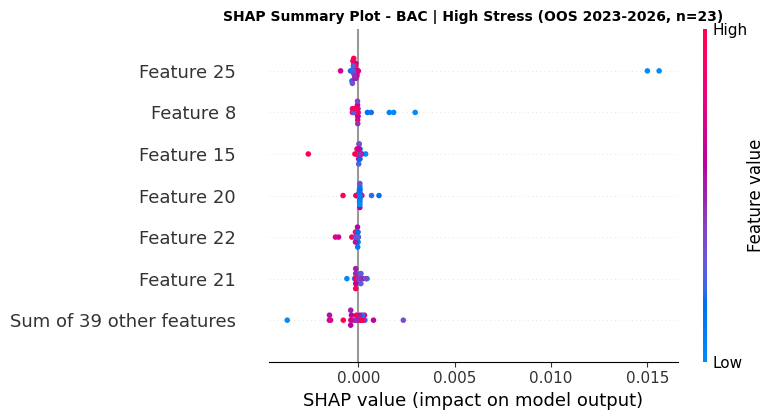

In [ ]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "CatBoost"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]
    years = df_single["Date"].dt.year

    # 1. Dò tìm chính xác cột biến động VIX
    vix_cols = [c for c in features_single if "VIX" in c.upper()]
    if not vix_cols:
        print(f"⚠️ Không tìm thấy feature VIX cho {ticker}. Bỏ qua...")
        continue
    vix_col_name = vix_cols[0]

    # 2. Xác định các chốt chặn Quantile từ tập TRAIN lịch sử (trước 2023) để chống Data Leakage
    train_mask = years < 2023
    vix_train_values = df_single.loc[train_mask, vix_col_name].values
    q33_train = np.quantile(vix_train_values, 1 / 3)
    q66_train = np.quantile(vix_train_values, 2 / 3)

    # 3. Lọc toàn bộ tập dữ liệu kiểm thử Out-of-Sample (OOS: 2023 - 2026)
    oos_mask = (years >= 2023) & (years <= 2026)
    df_oos = df_single.loc[oos_mask].reset_index(drop=True)

    if df_oos.empty:
        print(
            f"⚠️ Không có dữ liệu OOS (2023-2026) cho {ticker}. Bỏ qua..."
        )
        continue

    X_test_snapshot = df_oos[features_single].values
    vix_test_values = df_oos[vix_col_name].values

    # 4. Tính toán SHAP tổng thể cho toàn bộ giai đoạn OOS (2023-2026)
    current_model = fitted_models[TARGET_MODEL_NAME][ticker]
    explainer = shap.TreeExplainer(current_model)
    shap_vals_global = explainer(X_test_snapshot)

    # 5. Phân tách mặt nạ (masks) cho 3 vùng Stress dựa trên ngưỡng Train
    regime_masks = {
        "Low Stress": vix_test_values < q33_train,
        "Normal Regime": (vix_test_values >= q33_train)
        & (vix_test_values <= q66_train),
        "High Stress": vix_test_values > q66_train,
    }

    print("\n" + "=" * 90)
    print(
        f" PHÂN TÍCH SHAP THEO TRẠNG THÁI THỊ TRƯỜNG (REGIME-SPECIFIC SHAP OOS 2023-2026) | NGÂN HÀNG: {ticker}"
    )
    print("=" * 90)

    # Duyệt qua từng vùng cấu trúc thị trường độc lập
    for r_name, r_mask in regime_masks.items():
        n_samples = np.sum(r_mask)
        if n_samples == 0:
            print(
                f"\nTrạng thái [{r_name}] không có ngày giao dịch nào trong giai đoạn OOS (2023-2026)."
            )
            continue

        # Trích xuất phần dữ liệu SHAP tương ứng với Regime hiện tại
        shap_vals_regime = copy.deepcopy(shap_vals_global[r_mask])

        # Tính toán Importance cục bộ (Mean Absolute SHAP)
        shap_importance_regime = np.abs(shap_vals_regime.values).mean(
            axis=0
        )

        importance_df = pd.DataFrame({
            "Feature": features_single,
            "SHAP Importance": np.round(shap_importance_regime, 6),
        }).sort_values(by="SHAP Importance", ascending=False).reset_index(
            drop=True
        )

        print(
            f"\nTOP 5 FEATURES QUAN TRỌNG NHẤT - VÙNG TRẠNG THÁI: [{r_name.upper()}] ({n_samples} ngày OOS)"
        )
        print("-" * 70)
        print(importance_df.head(5).to_string(index=False))
        print("-" * 70)

        # 6. Vẽ biểu đồ trực quan Beeswarm cục bộ cho Regime
        plt.figure(figsize=(8.5, 3.5))
        shap.plots.beeswarm(shap_vals_regime, max_display=7, show=False)
        plt.title(
            f"SHAP Summary Plot - {ticker} | {r_name} (OOS 2023-2026, n={n_samples})",
            fontsize=10,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

    print("=" * 90)

# Economic Evaluation upgrade output

 KHỞI CHẠY BƯỚC 3: ECONOMIC EVALUATION - NÂNG CẤP TRANSACTION COST & EFFR SHARPE

==================== ECONOMIC EVALUATION: JPM ====================
(Áp dụng Chi phí ma sát: 7.5 bps | Tính Sharpe tích hợp chuỗi EFFR thực tế)

▶ MÔ HÌNH: XGBoost
------------------------------------------------------------------------------------------
                  Regime  Days  Net Cum Ret (%)  Ann Ret (%)  Sharpe (EFFR)  Max DD (%)  Win Rate (%)  Turnover (%)
        Low VIX (<14.91)   247             3.70         3.77        -0.3945       -2.12         63.16          0.40
Normal VIX (14.91-17.87)   254            10.26        10.17         0.4255       -7.20         53.91          0.39
       High VIX (>17.87)   250            16.15        16.28         0.6223      -21.78         58.82          0.40
------------------------------------------------------------------------------------------

▶ MÔ HÌNH: LightGBM
----------------------------------------------------------------------------------------

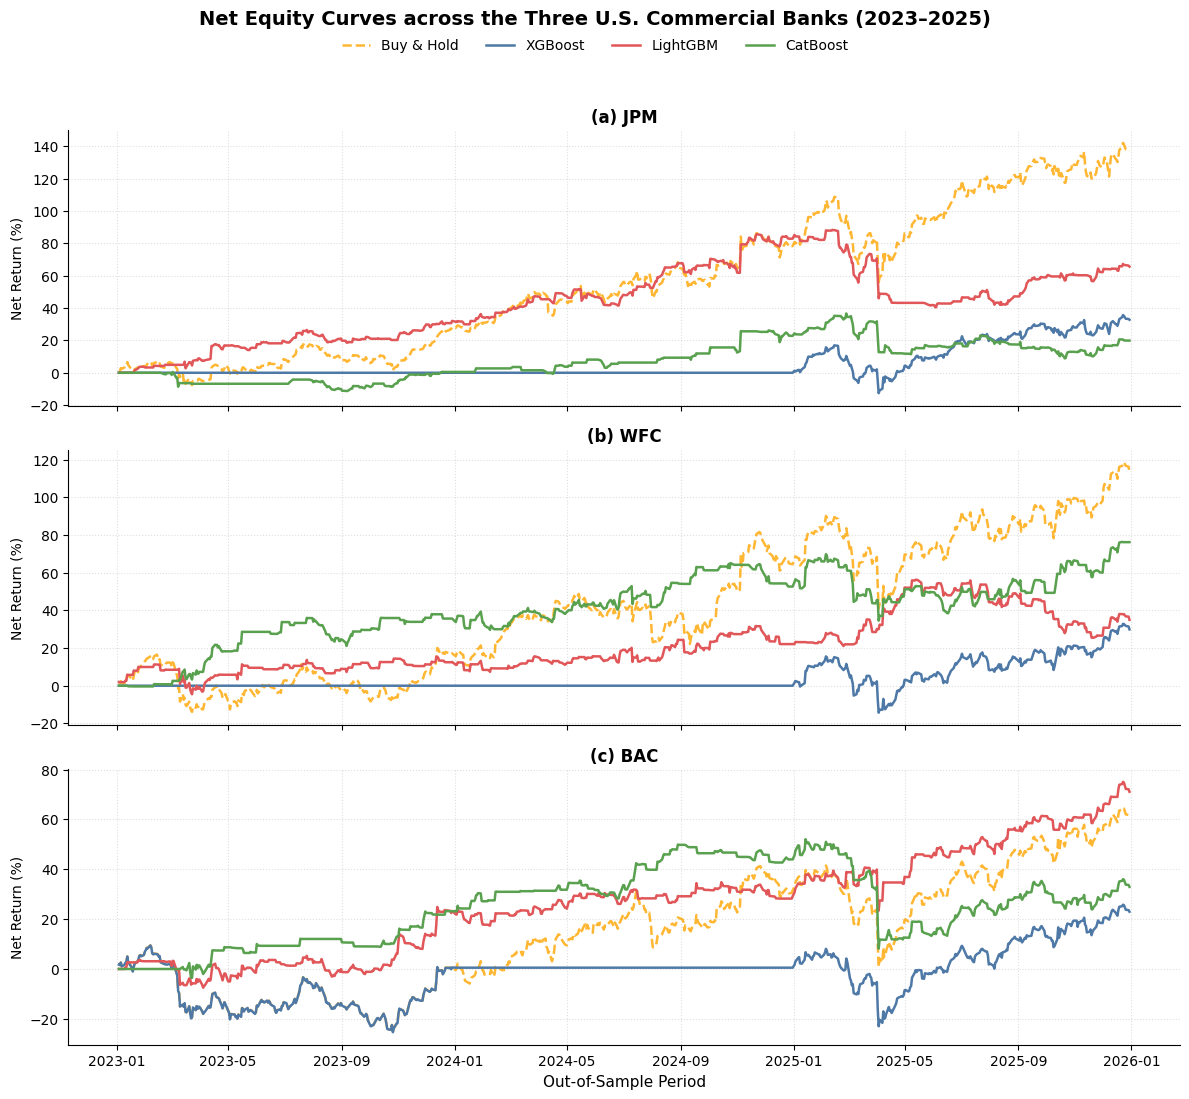



OVERALL ECONOMIC PERFORMANCE
Bank    Model  Net Return (%)  Sharpe  Max DD (%)  Win Rate (%)  Turnover (%)
 JPM  XGBoost           32.79   0.400      -25.29         56.63          0.13
 JPM LightGBM           65.67   0.833      -25.43         57.49         41.94
 JPM CatBoost           19.93   0.162      -20.31         56.22         29.03
 WFC  XGBoost           29.89   0.321      -25.86         54.22          0.13
 WFC LightGBM           34.98   0.382      -19.72         54.36         40.21
 WFC CatBoost           76.24   0.856      -20.78         55.74         35.95
 BAC  XGBoost           22.99   0.209      -31.80         51.90          0.27
 BAC LightGBM           71.12   0.863      -12.30         55.23         41.94
 BAC CatBoost           32.95   0.387      -28.89         56.60         30.23


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("==========================================================================================")
print(" KHỞI CHẠY BƯỚC 3: ECONOMIC EVALUATION - NÂNG CẤP TRANSACTION COST & EFFR SHARPE")
print("==========================================================================================")

tickers = ["JPM", "WFC", "BAC"]
models = ["XGBoost", "LightGBM", "CatBoost"]

# ==========================================================
# Store Overall Economic Results (for Table 11)
# ==========================================================
overall_economic_results = []

test_years = [2023, 2024, 2025]

# CẤU HÌNH CHI PHÍ GIAO DỊCH (7.5 bps = 0.00075 cho mỗi lần đảo vị thế)
TC_BPS = 7.5
TRANSACTION_COST = TC_BPS / 10000

# =============================================================================
# FIGURE 5 - NET EQUITY CURVES (3 SUBFIGURES)
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 11),
    sharex=True
)

subplot_labels = ["(a)", "(b)", "(c)"]



for ticker in tickers:
    if ticker not in all_results_master or ticker not in all_dfs_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]
    results_single = all_results_master[ticker]

    # 1. Đồng bộ chuỗi dữ liệu Out-of-Sample
    test_full_mask = df_single["Date"].dt.year.isin(test_years)
    df_oos_full = df_single.loc[test_full_mask].reset_index(drop=True)
    dates_oos = df_oos_full["Date"]

    # 2. Xử lý Lại suất phi rủi ro EFFR (Đổi từ % năm sang tỷ lệ ngày: EFFR / 100 / 252)
    effr_cols = [c for c in df_single.columns if "EFFR" in c.upper()]
    if effr_cols:
        # Giả định nếu có cột gốc EFFR dạng số phần trăm nền (ví dụ: 5.25), chia cho 25200 để ra tỷ lệ ngày
        daily_rf = df_oos_full[effr_cols[0]].values / 25200
    else:
        # Nếu không tìm thấy cột EFFR, sử dụng mức nền trung bình 4.5% năm của giai đoạn 2023-2025 làm fallback
        daily_rf = np.full(len(df_oos_full), 4.5 / 25200)

    # 3. Dò tìm và phân tách Regime VIX theo phân vị
    vix_cols = [c for c in features_single if "VIX" in c.upper()]
    if not vix_cols:
        print(f"⚠️ Không tìm thấy feature VIX cho {ticker}. Bỏ qua phân tách regime...")
        continue

    vix_values = df_oos_full[vix_cols[0]].values
    q33 = np.quantile(vix_values, 1/3)
    q66 = np.quantile(vix_values, 2/3)

    regimes = {
        f"Low VIX (<{q33:.2f})": vix_values < q33,
        f"Normal VIX ({q33:.2f}-{q66:.2f})": (vix_values >= q33) & (vix_values <= q66),
        f"High VIX (>{q66:.2f})": vix_values > q66
    }

    print(f"\n==================== ECONOMIC EVALUATION: {ticker} ====================")
    print(f"(Áp dụng Chi phí ma sát: {TC_BPS} bps | Tính Sharpe tích hợp chuỗi EFFR thực tế)")

    # Lưu trữ các chuỗi lợi nhuận ròng để vẽ đồ thị tổng thể ở cuối
    net_strat_returns_all_models = {}


    # Duyệt qua từng mô hình học máy
    for model_name in models:
        actuals = np.array(results_single[model_name]["actuals"])
        preds = np.array(results_single[model_name]["preds"])

        # Tạo tín hiệu giao dịch dựa trên ngưỡng Mean động
        mean_threshold = np.mean(preds)
        signals = np.where(preds > mean_threshold, 1, 0)

        # Lợi nhuận thô (Chưa trừ phí)
        gross_strat_returns = signals * actuals

        # TÍNH TOÁN CHI PHÍ MA SÁT GIAO DỊCH THỰC TẾ TRÊN TỪNG PHIÊN
        # Xác định các điểm thay đổi vị thế: Ngày đầu tiên mở vị thế + các ngày thay đổi trạng thái
        trades = np.abs(np.diff(signals))
        trade_costs = np.zeros(len(signals))
        trade_costs[1:] = trades * TRANSACTION_COST
        if signals[0] == 1:
            trade_costs[0] = TRANSACTION_COST # Tính phí cho phiên mở lệnh Long đầu tiên trong tập dữ liệu

        # Lợi nhuận ròng thực tế sau khi trừ chi phí ma sát
        net_strat_returns = gross_strat_returns - trade_costs
        net_strat_returns_all_models[model_name] = net_strat_returns

        # ==========================================================
        # OVERALL ECONOMIC PERFORMANCE
        # ==========================================================

        cum_return = (1 + net_strat_returns).cumprod() - 1
        final_return = cum_return.iloc[-1] if isinstance(cum_return, pd.Series) else cum_return[-1]
        ann_return = (1 + final_return) ** (252 / len(actuals)) - 1
        excess = net_strat_returns - daily_rf
        daily_std = np.std(net_strat_returns)
        overall_sharpe = (
            excess.mean() / daily_std * np.sqrt(252)
            if daily_std > 0 else 0
        )
        equity = pd.Series((1 + net_strat_returns).cumprod())
        running_max = equity.cummax()
        drawdown = (equity - running_max) / running_max
        max_dd = drawdown.min()
        turnover = np.sum(np.abs(np.diff(signals))) / len(signals)

        # Overall Win Rate
        active_trades = actuals[signals == 1]

        overall_win_rate = (
            np.mean(active_trades > 0) * 100
            if len(active_trades) > 0 else 0
        )

        overall_economic_results.append({
            "Bank": ticker,
            "Model": model_name,
            "Net Return (%)": round(final_return * 100,2),
            "Sharpe": round(overall_sharpe,3),
            "Max DD (%)": round(max_dd*100,2),
            "Win Rate (%)": round(overall_win_rate,2),
            "Turnover (%)": round(turnover*100,2)
        })

        econ_regime_report = []

        # Phân tích hiệu quả kinh tế trên từng môi trường VIX
        for r_name, mask in regimes.items():
            r_actuals = actuals[mask]
            r_net_returns = net_strat_returns[mask]
            r_signals = signals[mask]
            r_daily_rf = daily_rf[mask]

            if len(r_actuals) == 0:
                continue

            # 1. Lợi nhuận tích lũy ròng (Net Cumulative Return)
            r_cum_strat = (1 + r_net_returns).cumprod() - 1
            final_cum_ret = r_cum_strat[-1] if len(r_cum_strat) > 0 else 0

            # 2. Lợi nhuận chuẩn hóa năm (Annualized Return)
            n_days = len(r_actuals)
            ann_ret = (1 + final_cum_ret) ** (252 / n_days) - 1 if final_cum_ret > -1 else -1

            # 3. Hệ số Sharpe Ratio chuẩn (Trừ chuỗi Risk-Free Rate EFFR của chính Regime đó)
            excess_returns = r_net_returns - r_daily_rf
            daily_std = r_net_returns.std() # Độ lệch chuẩn tính trên tổng danh mục ròng của chiến lược
            sharpe = (excess_returns.mean() / daily_std) * np.sqrt(252) if daily_std != 0 else 0

            # 4. Sụt giảm tài sản tối đa ròng (Net Max Drawdown)
            if n_days > 1:
                equity_curve = pd.Series((1 + r_net_returns).cumprod())
                running_max = equity_curve.cummax()
                drawdown = (equity_curve - running_max) / running_max
                max_dd = drawdown.min()
            else:
                max_dd = 0

            # 5. Tỷ lệ chiến thắng thực tế
            active_trades = r_actuals[r_signals == 1]
            win_rate = np.mean(active_trades > 0) * 100 if len(active_trades) > 0 else 0

            # 6. Tần suất giao dịch (Turnover)
            pos_changes = np.sum(np.abs(np.diff(r_signals))) if len(r_signals) > 1 else 0
            turnover = pos_changes / n_days



            econ_regime_report.append({
                "Regime": r_name,
                "Days": n_days,
                "Net Cum Ret (%)": round(final_cum_ret * 100, 2),
                "Ann Ret (%)": round(ann_ret * 100, 2),
                "Sharpe (EFFR)": round(sharpe, 4),
                "Max DD (%)": round(max_dd * 100, 2),
                "Win Rate (%)": round(win_rate, 2),
                "Turnover (%)": round(turnover * 100, 2),
            })

        print(f"\n▶ MÔ HÌNH: {model_name}")
        print("-" * 90)
        print(pd.DataFrame(econ_regime_report).to_string(index=False))
        print("-" * 90)

    # ==============================================================
    # DRAW EQUITY CURVE INTO SUBPLOT
    # ==============================================================

    ax = axes[tickers.index(ticker)]

    sample_actuals = np.array(results_single["LightGBM"]["actuals"])

    benchmark_curve = ((1 + sample_actuals).cumprod() - 1) * 100

    ax.plot(
        dates_oos,
        benchmark_curve,
        linestyle="--",
        color="orange",
        linewidth=1.8,
        alpha=0.8,
        label="Buy & Hold"
    )

    colors={
    "XGBoost":"#4E79A7",
    "LightGBM":"#E15759",
    "CatBoost":"#59A14F"
    }

    for model_name in models:

        strategy_curve = (
            (1 + net_strat_returns_all_models[model_name]).cumprod() - 1
        ) * 100

        ax.plot(
            dates_oos,
            strategy_curve,
            linewidth=1.8,
            color=colors[model_name],
            label=model_name
        )

    ax.set_title(
        f"{subplot_labels[tickers.index(ticker)]} {ticker}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel("Net Return (%)", fontsize=10)

    ax.grid(
        True,
        linestyle=":",
        alpha=0.4
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    print("=" * 88)


# =============================================================================
# FINALIZE FIGURE
# =============================================================================

axes[-1].set_xlabel(
    "Out-of-Sample Period",
    fontsize=11
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=4,
    frameon=False,
    fontsize=10
)

fig.suptitle(
    "Net Equity Curves across the Three U.S. Commercial Banks (2023–2025)",
    fontsize=14,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "Figure5_EquityCurves.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


print("\n")
print("="*95)
print("OVERALL ECONOMIC PERFORMANCE")
print("="*95)

table11 = pd.DataFrame(overall_economic_results)

print(table11.to_string(index=False))
